<a href="https://colab.research.google.com/github/Brwonggg/Datathon/blob/main/fraud_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NTU Datathon 2026 — Track 2: Intelligent Financial Fraud Detection

**Problem statement.** *How can machine learning identify potentially fraudulent financial transactions while minimising unnecessary disruption to legitimate customers?*

**Scoring (Round 1):** 60% metrics (**PR-AUC, F1, Recall**) on a hidden private test set · 40% understanding (why this model, what it assumes).

**How this notebook keeps its numbers honest**
* A **20% hold-out is locked away** at the start and used exactly **once**, at the end.
* Everything else (model choice, tuning, calibration, threshold) is decided on **5-fold out-of-fold (OOF)** predictions of the remaining 80%, with features fitted **inside each fold**.
* Model scores are **calibrated**, so `fraud_probability = 0.2` really means about a 1-in-5 chance of fraud.
* The final model is retrained on all data, and its calibration and threshold are re-learned from **its own** OOF predictions.

**Sections:** 1 Setup · 2 Problem · 3 EDA & data audit · 4 Cleaning & train/test shift · 5 Features · 6 Validation design · 7 Model comparison · 8 Tuning · 9 Calibration & threshold · 10 Hold-out report · 11 Calibration check · 12 Business view · 13 Interpretation · 14 Assumptions · 15 Final model · 16 Predictions

> **Colab:** `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`.

## 1. Setup

In [33]:
import os, sys, subprocess, time, re, json, pickle, warnings, random
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

# Colab ships pandas/sklearn/xgboost/lightgbm; install the rest quietly.
if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'optuna', 'catboost', 'imbalanced-learn', 'shap'], check=False)

import numpy as np
import pandas as pd

def has_gpu():
    try:
        return subprocess.run(['nvidia-smi'], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False

GPU = has_gpu()
SEED = 42
random.seed(SEED); np.random.seed(SEED); os.environ['PYTHONHASHSEED'] = str(SEED)
print(f'Colab: {IN_COLAB} | GPU: {GPU} | pandas {pd.__version__} | numpy {np.__version__}')

Colab: True | GPU: True | pandas 2.2.3 | numpy 2.1.3


## 1b. Configuration
Pre-filled for the NTU Track 2 dataset. Use `'auto'` to let the notebook detect a column, or `None` when the dataset has no such column.

In [34]:
AUTO = 'auto'

# ---------- where is the data? ----------
DATA_SOURCE = os.environ.get('DATA_SOURCE', 'drive' if IN_COLAB else 'local')    # 'drive' | 'upload' | 'local'
DRIVE_DIR   = '/content/drive/MyDrive/Track 2 Dataset'  # your Google Drive folder with both CSVs
LOCAL_DIR   = os.environ.get('DATA_DIR', './data')     # used when DATA_SOURCE == 'local'
TRAIN_FILE  = os.environ.get('TRAIN_FILE', 'Track 2 Training Dataset.csv')
TEST_FILE   = os.environ.get('TEST_FILE',  'Track 2 Testing Dataset.csv')

# ---------- schema (declared explicitly; never inferred for the label) ----------
TARGET         = 'fraud'
POSITIVE_LABEL = 1                     # the value of TARGET that means fraud
ID_COL         = 'id'
TIME_COL       = None                  # no timestamp in this dataset (transaction_hour is NOT a chronology)
TIME_UNIT      = AUTO                  # for numeric time columns: 'seconds' | 'hours'
AMOUNT_COL     = 'transaction_amount'
ENTITY_COLS    = []                    # no card / customer / merchant ids in this dataset

# dataset-specific behaviour columns (None = not available)
HOUR_COL        = 'transaction_hour'
TX_1H_COL       = 'transactions_last_1h'
TX_24H_COL      = 'transactions_last_24h'
SPEND_24H_COL   = 'spend_last_24h'
ACCOUNT_AGE_COL = 'account_age'
NEW_DEVICE_COL  = 'new_device'
CHANNEL_COL     = 'transaction_channel'

# ---------- preprocessing ----------
USE_MISSING_FLAGS = False   # see the missing-value audit in section 3 before switching on
ONEHOT_MAX        = 30      # categoricals with more levels get frequency encoding instead

# ---------- validation & modelling ----------
TRAIN_ROWS     = 2000       # SMOKE TEST: train on the first N rows only. Set to None for the real run!
HOLDOUT_FRAC   = 0.20
N_FOLDS        = 5
USE_CATBOOST   = True
TRY_SMOTE      = False      # optional comparison only; distorts probabilities, so off by default
N_TRIALS       = int(os.environ.get('N_TRIALS', 10 if TRAIN_ROWS else 60))   # Optuna trials ...
OPTUNA_TIMEOUT = int(os.environ.get('OPTUNA_TIMEOUT', 900))  # ... or seconds, whichever comes first
CALIBRATION    = 'sigmoid'  # 'sigmoid' (Platt, robust with few frauds) | 'isotonic' | 'none'

# ---------- decision rule ----------
THRESHOLD_STRATEGY = 'f1'   # 'f1' (scored metric) | 'f2' (recall-leaning) | 'cost' (expected loss vs review cost)
COST_FN_FACTOR     = 1.0    # share of a missed fraud's amount that is lost
COST_FP            = 5.0    # cost of reviewing / disrupting one flagged transaction ($)

# ---------- submission format ----------
SUB_ID_NAME    = None       # None -> ID_COL (or 'id')
SUB_LABEL_NAME = None       # None -> TARGET
INCLUDE_PROBA_IN_SUBMISSION = False   # True adds a calibrated 'fraud_probability' column

# Local testing hook: override any of the above with a JSON env var. Leave unset in Colab.
globals().update(json.loads(os.environ.get('SCHEMA_OVERRIDES', '{}')))

In [35]:
if DATA_SOURCE == 'drive':
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = DRIVE_DIR
elif DATA_SOURCE == 'upload':
    DATA_DIR = '/content' if IN_COLAB else '.'
    missing = [f for f in (TRAIN_FILE, TEST_FILE) if not os.path.exists(os.path.join(DATA_DIR, f))]
    if missing:
        from google.colab import files
        print('Please upload:', missing)
        files.upload()
else:
    DATA_DIR = LOCAL_DIR

def read_any(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == '.parquet': return pd.read_parquet(path)
    if ext in ('.xlsx', '.xls'): return pd.read_excel(path)
    return pd.read_csv(path)

train_raw = read_any(os.path.join(DATA_DIR, TRAIN_FILE))
if TRAIN_ROWS:
    train_raw = train_raw.head(TRAIN_ROWS).reset_index(drop=True)
    print(f'*** SMOKE TEST: using only the first {TRAIN_ROWS:,} training rows '
          f'({int((train_raw[TARGET] == POSITIVE_LABEL).sum())} frauds). Set TRAIN_ROWS = None for the real run. ***')
test_path = os.path.join(DATA_DIR, TEST_FILE)
test_raw  = read_any(test_path) if os.path.exists(test_path) else None
print('train:', train_raw.shape, '| test:', None if test_raw is None else test_raw.shape)
train_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
*** SMOKE TEST: using only the first 2,000 training rows (28 frauds). Set TRAIN_ROWS = None for the real run. ***
train: (2000, 12) | test: (12000, 11)


,id,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h,fraud
0,FR016993,55.03,16,retail,SG,ecommerce,27.0,1791.34,1192.0,0.0,5.0,0
1,FR002433,20.75,1,gaming,SG,mobile_app,3.0,217.96,3073.0,0.0,0.0,0
2,FR009253,21.51,9,entertainment,SG,mobile_app,3.0,62.71,985.0,0.0,0.0,0
3,FR004881,813.98,16,utilities,GB,mobile_app,2.0,110.48,653.0,0.0,1.0,0
4,FR014830,13.54,20,food_delivery,SG,card_present,4.0,114.98,79.0,0.0,0.0,0


In [36]:
# ---------- resolve 'auto' columns and validate the schema ----------
def _match(cols, pattern):
    return [c for c in cols if re.search(pattern, str(c), flags=re.I)]

def detect_target(tr, te):
    binary = lambda c: tr[c].dropna().nunique() == 2
    if te is not None:
        extra = [c for c in tr.columns if c not in te.columns and binary(c)]
        if len(extra) == 1:
            return extra[0]
    named = sorted([c for c in _match(tr.columns, r'fraud|label|class|target|^y$') if binary(c)],
                   key=lambda c: ('flag' in c.lower(), len(c)))
    if named:
        return named[0]
    raise ValueError('Could not detect the target column; set TARGET.')

def detect_id(tr):
    cands = _match(tr.columns, r'^id$|^index$|trans.*id|txn.*id|^tx_?id|_id$|^id_|unnamed')
    unique = sorted([c for c in cands if tr[c].is_unique], key=lambda c: 'unnamed' in c.lower())
    return unique[0] if unique else None

def detect_time(tr):
    for c in _match(tr.columns, r'timestamp|datetime|date|time|^step$|_ts$'):
        if pd.api.types.is_numeric_dtype(tr[c]):
            return c, 'numeric', ('hours' if re.search(r'step|hour', c, re.I) else 'seconds')
        if pd.to_datetime(tr[c].head(1000), errors='coerce').notna().mean() > 0.9:
            return c, 'datetime', None
    return None, None, None

def detect_amount(tr, exclude):
    for pat in (r'amount|amt', r'value|price|sum'):
        for c in _match(tr.columns, pat):
            if c not in exclude and pd.api.types.is_numeric_dtype(tr[c]) and not re.search(r'old|new|bal', c, re.I):
                return c
    return None

def detect_entities(tr, exclude):
    pat = (r'card|cust|client|account|acct|user|merchant|device|ip_?addr|email|'
           r'name_?orig|name_?dest|terminal|sender|receiver|payer|payee|beneficiary')
    id_like = r'(_id$|^id_|_no$|number|_key$|_code$)'
    out = []
    for c in _match(tr.columns, pat):
        if c in exclude: continue
        # numeric columns only count as entities when the name says they are ids (not account_age!)
        if pd.api.types.is_numeric_dtype(tr[c]) and not re.search(id_like, c, re.I): continue
        if 50 < tr[c].nunique() < 0.9 * len(tr):
            out.append(c)
    return out[:4]

if TARGET == AUTO:   TARGET = detect_target(train_raw, test_raw)
if ID_COL == AUTO:   ID_COL = detect_id(train_raw)
if TIME_COL == AUTO:
    TIME_COL, TIME_KIND, _unit = detect_time(train_raw)
elif TIME_COL:
    TIME_KIND = 'numeric' if pd.api.types.is_numeric_dtype(train_raw[TIME_COL]) else 'datetime'
    _unit = 'hours' if re.search(r'step|hour', TIME_COL, re.I) else 'seconds'
else:
    TIME_KIND, _unit = None, None
TIME_UNIT = _unit if TIME_UNIT == AUTO else TIME_UNIT
_excl = {TARGET, ID_COL, TIME_COL}
if AMOUNT_COL == AUTO:  AMOUNT_COL = detect_amount(train_raw, _excl)
if ENTITY_COLS == AUTO: ENTITY_COLS = detect_entities(train_raw, _excl | {AMOUNT_COL})
if HOUR_COL == AUTO:    HOUR_COL = next((c for c in _match(train_raw.columns, r'hour') if pd.api.types.is_numeric_dtype(train_raw[c])), None)

# configured columns that are not in the data are switched off (so the notebook runs on any schema)
for _name in ['ID_COL', 'AMOUNT_COL', 'HOUR_COL', 'TX_1H_COL', 'TX_24H_COL', 'SPEND_24H_COL',
              'ACCOUNT_AGE_COL', 'NEW_DEVICE_COL', 'CHANNEL_COL']:
    if globals()[_name] and globals()[_name] not in train_raw.columns:
        print(f'{_name}={globals()[_name]!r} not found in the data -> None'); globals()[_name] = None
ENTITY_COLS = [c for c in ENTITY_COLS if c in train_raw.columns]
assert TARGET in train_raw.columns, f'TARGET {TARGET!r} not in the training data'

# ---------- label: explicit positive class, never inferred from prevalence ----------
train_raw = train_raw.dropna(subset=[TARGET]).reset_index(drop=True)
labels = set(pd.unique(train_raw[TARGET]))
if POSITIVE_LABEL in labels:
    train_raw[TARGET] = (train_raw[TARGET] == POSITIVE_LABEL).astype(int)
elif labels <= {True, False}:
    train_raw[TARGET] = train_raw[TARGET].astype(int)
else:
    raise ValueError(f'TARGET values are {sorted(map(str, labels))}; set POSITIVE_LABEL to the one meaning fraud.')

SUB_ID_NAME = SUB_ID_NAME or ID_COL or 'id'
SUB_LABEL_NAME = SUB_LABEL_NAME or TARGET
print(f'TARGET={TARGET} (fraud = {POSITIVE_LABEL!r}) | ID_COL={ID_COL} | TIME_COL={TIME_COL} | AMOUNT_COL={AMOUNT_COL}')
print(f'ENTITY_COLS={ENTITY_COLS} | HOUR_COL={HOUR_COL}')
print(f'window features: 1h={TX_1H_COL}, 24h={TX_24H_COL}, spend24h={SPEND_24H_COL} | age={ACCOUNT_AGE_COL} | '
      f'new_device={NEW_DEVICE_COL} | channel={CHANNEL_COL}')

TARGET=fraud (fraud = 1) | ID_COL=id | TIME_COL=None | AMOUNT_COL=transaction_amount
ENTITY_COLS=[] | HOUR_COL=transaction_hour
window features: 1h=transactions_last_1h, 24h=transactions_last_24h, spend24h=spend_last_24h | age=account_age | new_device=new_device | channel=transaction_channel


## 2. Understanding the problem

* **Rare positive class.** Fraud is under 2% of transactions here. A model that predicts *"never fraud"* gets ~98% accuracy and catches nothing, so **accuracy is the wrong metric**.
* **Two kinds of error, two costs.** A *false negative* (missed fraud) is a direct financial loss. A *false positive* (legitimate transaction blocked) is customer friction and review cost: the "unnecessary disruption" in the problem statement.
* **Metrics we are scored on**
  * **PR-AUC (average precision)**: how well the model *ranks* fraud above legitimate transactions, focused on the fraud class. Its random baseline equals the fraud rate (~1.8%); ROC-AUC's baseline is 0.5 and looks flattering on imbalanced data.
  * **Recall**: the share of fraud we catch.
  * **F1**: the balance between catching fraud and not flagging legitimate customers.
* **Ranking vs probability.** A model can rank transactions well (high PR-AUC) and still output numbers that are not true probabilities, especially when class weights are used. We treat these as two separate jobs: **rank** with a tuned booster, then **calibrate** so the output can be read as a probability.
* **Design consequences:** choose models by out-of-fold PR-AUC, handle imbalance with class weights, calibrate, then choose the decision threshold explicitly instead of using 0.5.

## 3. Exploratory data analysis & data audit

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

df = train_raw
print('Shape:', df.shape)
info = pd.DataFrame({'dtype': df.dtypes.astype(str), 'n_unique': df.nunique(),
                     'missing_%': (df.isna().mean() * 100).round(2)})
display(info)
display(df.describe(include='all').T)

Shape: (2000, 12)


,dtype,n_unique,missing_%
id,object,2000,0.00
transaction_amount,float64,1922,0.00
transaction_hour,int64,24,0.00
merchant_category,object,11,0.55
country,object,10,0.80
transaction_channel,object,4,0.50
transactions_last_24h,float64,24,0.80
spend_last_24h,float64,1917,0.75
account_age,float64,1246,0.50
new_device,float64,2,0.85


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2000,2000,FR009876,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_amount,2000.0,NaN,NaN,NaN,233.252135,579.22978,2.5,31.79,70.98,189.2625,5898.4
transaction_hour,2000.0,NaN,NaN,NaN,11.506,6.917289,0.0,6.0,12.0,17.25,23.0
merchant_category,1989,11,grocery,378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1984,10,SG,1387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_channel,1990,4,card_present,757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transactions_last_24h,1984.0,NaN,NaN,NaN,4.671875,2.723924,1.0,3.0,4.0,6.0,27.0
spend_last_24h,1985.0,NaN,NaN,NaN,523.77467,920.265819,0.0,94.97,220.08,512.47,15670.31
account_age,1990.0,NaN,NaN,NaN,1031.723618,931.93189,5.0,338.5,773.0,1461.75,4000.0
new_device,1983.0,NaN,NaN,NaN,0.082199,0.274736,0.0,0.0,0.0,0.0,1.0


Fraud rate: 1.4000%  (28 fraud / 2,000 rows)  -> 1 fraud per 71 transactions


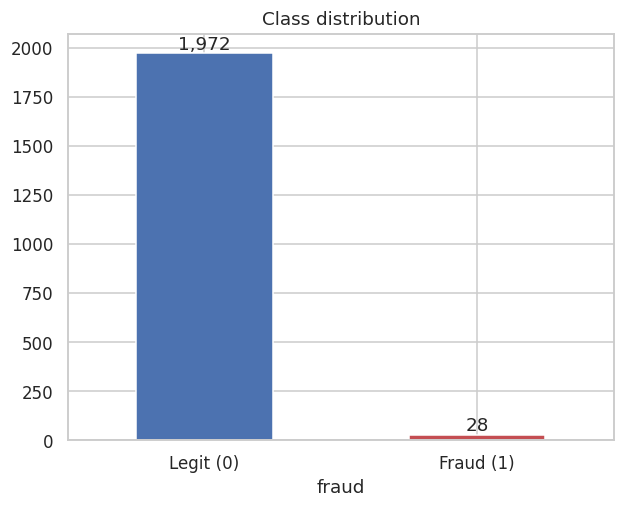

In [6]:
rate = df[TARGET].mean()
print(f'Fraud rate: {rate:.4%}  ({df[TARGET].sum():,} fraud / {len(df):,} rows)  -> 1 fraud per {1/rate:.0f} transactions')
ax = df[TARGET].value_counts().sort_index().plot.bar(color=['#4C72B0', '#C44E52'])
ax.set_title('Class distribution'); ax.set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)
for p in ax.patches: ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

**Insight:** _fill in: how imbalanced the data is and what that means for metrics and validation (only ~350 frauds, so every fold matters)._

,|corr with fraud|
spend_last_24h,0.126460
transactions_last_24h,0.117977
transactions_last_1h,0.093556
transaction_amount,0.070001
transaction_hour,0.048103
account_age,0.034176


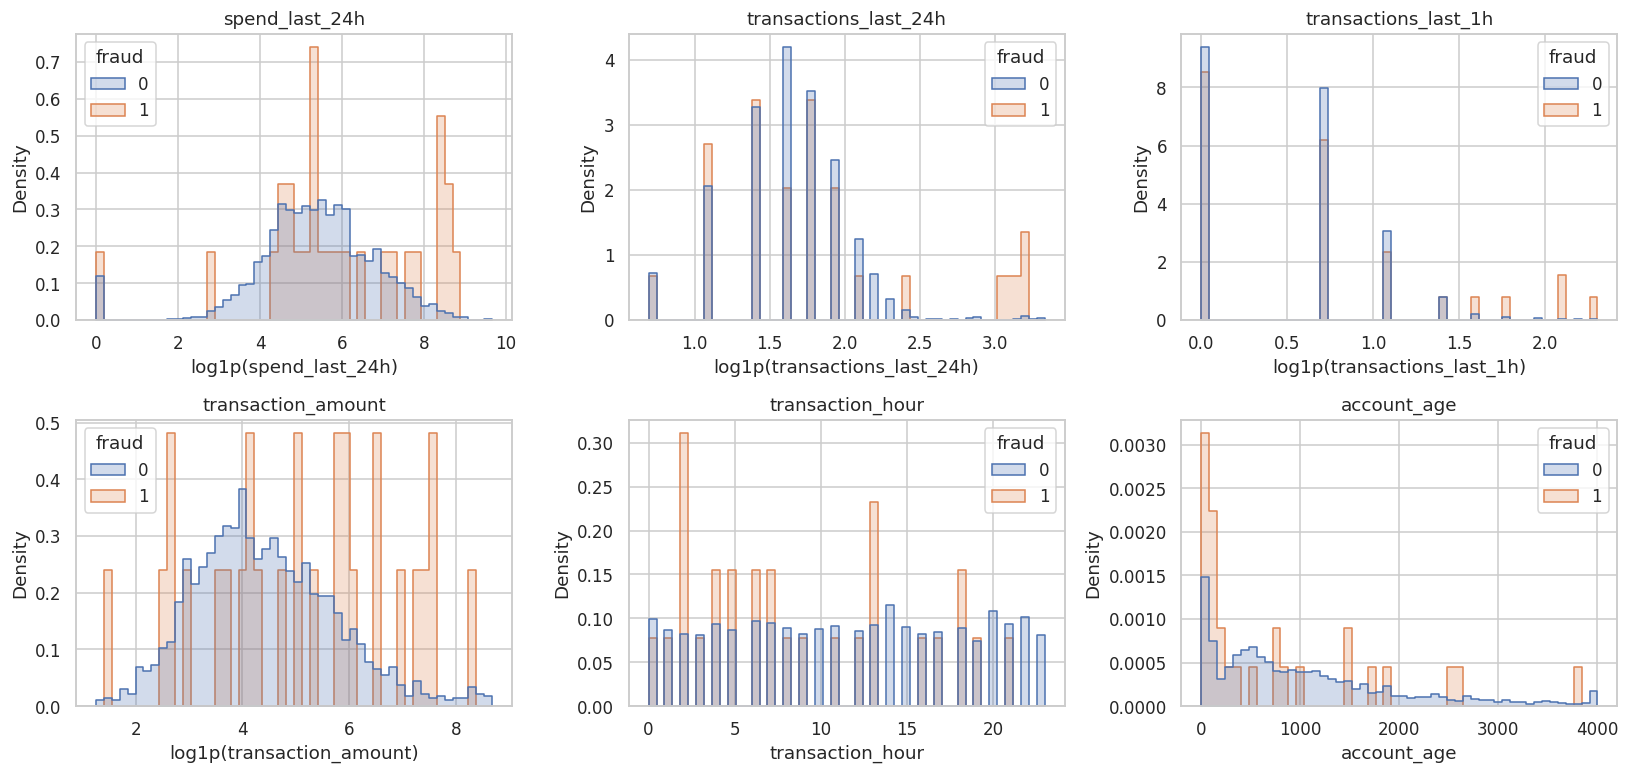

In [7]:
eda = df
skip = {TARGET, ID_COL, TIME_COL}
num_cols = [c for c in eda.columns if c not in skip and pd.api.types.is_numeric_dtype(eda[c]) and eda[c].nunique() > 2]
corr_t = eda[num_cols].corrwith(eda[TARGET]).abs().sort_values(ascending=False)
top_num = corr_t.index[:12].tolist()
display(corr_t.to_frame('|corr with fraud|').head(15))
if top_num:
    ncol = 3; nrow = int(np.ceil(len(top_num) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.6 * nrow)); axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, top_num):
        x = eda[c]
        if x.min() >= 0 and x.skew() > 2:
            x = np.log1p(x); ax.set_xlabel(f'log1p({c})')
        sns.histplot(x=x, hue=eda[TARGET], stat='density', common_norm=False, bins=50, element='step', ax=ax)
        ax.set_title(c)
    for ax in axes[len(top_num):]: ax.axis('off')
    plt.tight_layout(); plt.show()

**Insight:** _fill in: which numeric features separate fraud from legitimate transactions._

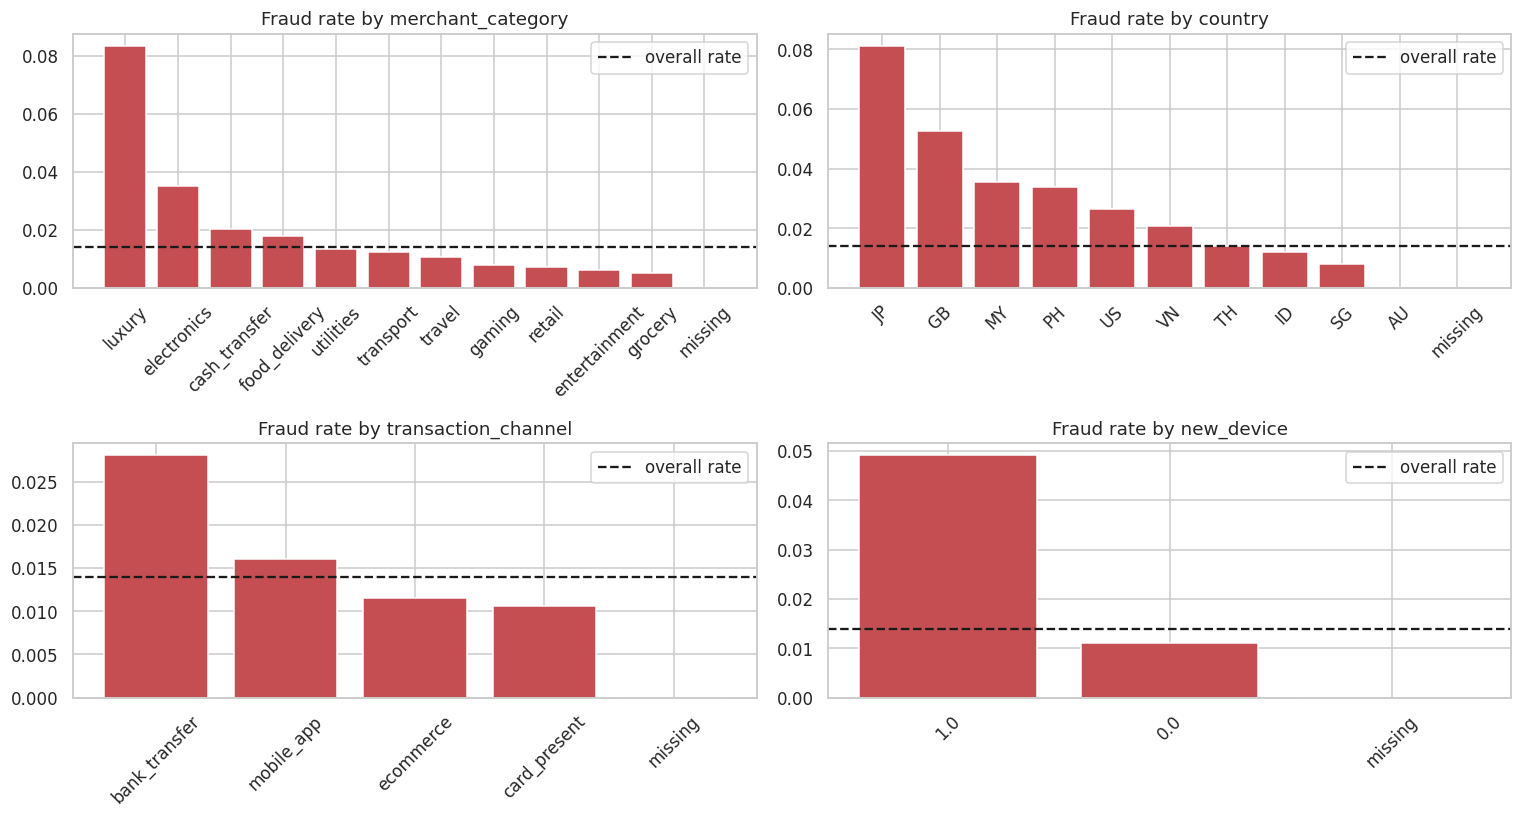

In [8]:
cat_cols = [c for c in eda.columns if c not in skip and not pd.api.types.is_numeric_dtype(eda[c]) and 1 < eda[c].nunique() <= 30]
bin_cols = [c for c in eda.columns if c not in skip and pd.api.types.is_numeric_dtype(eda[c]) and eda[c].nunique() == 2]
show = (cat_cols + bin_cols)[:8]
if show:
    nrow = int(np.ceil(len(show) / 2))
    fig, axes = plt.subplots(nrow, 2, figsize=(14, 3.8 * nrow)); axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, show):
        r = eda.groupby(eda[c].astype(object).fillna('missing'))[TARGET].agg(['mean', 'size']).sort_values('mean', ascending=False)
        ax.bar(r.index.astype(str), r['mean'], color='#C44E52'); ax.axhline(rate, ls='--', c='k', label='overall rate')
        ax.set_title(f'Fraud rate by {c}'); ax.tick_params(axis='x', rotation=45); ax.legend()
    for ax in axes[len(show):]: ax.axis('off')
    plt.tight_layout(); plt.show()

**Insight:** _fill in: which categories, channels or the new-device flag carry elevated fraud risk._

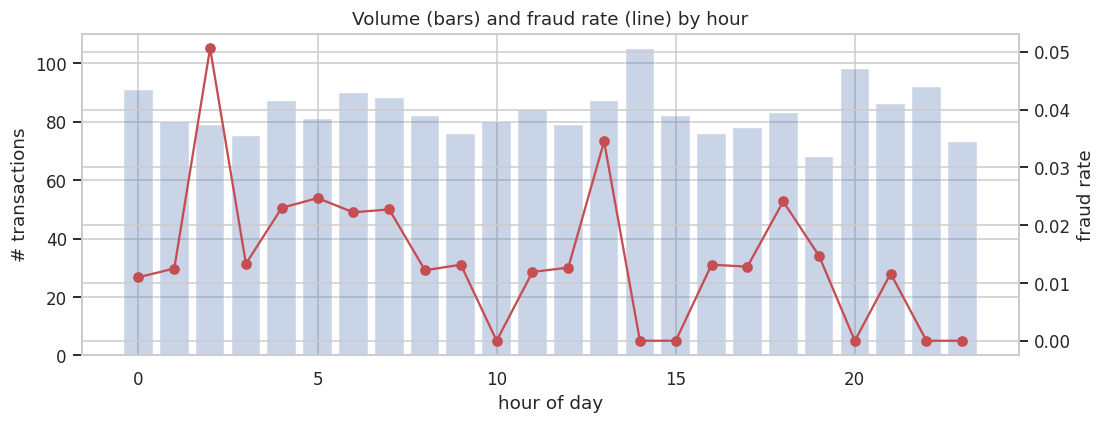

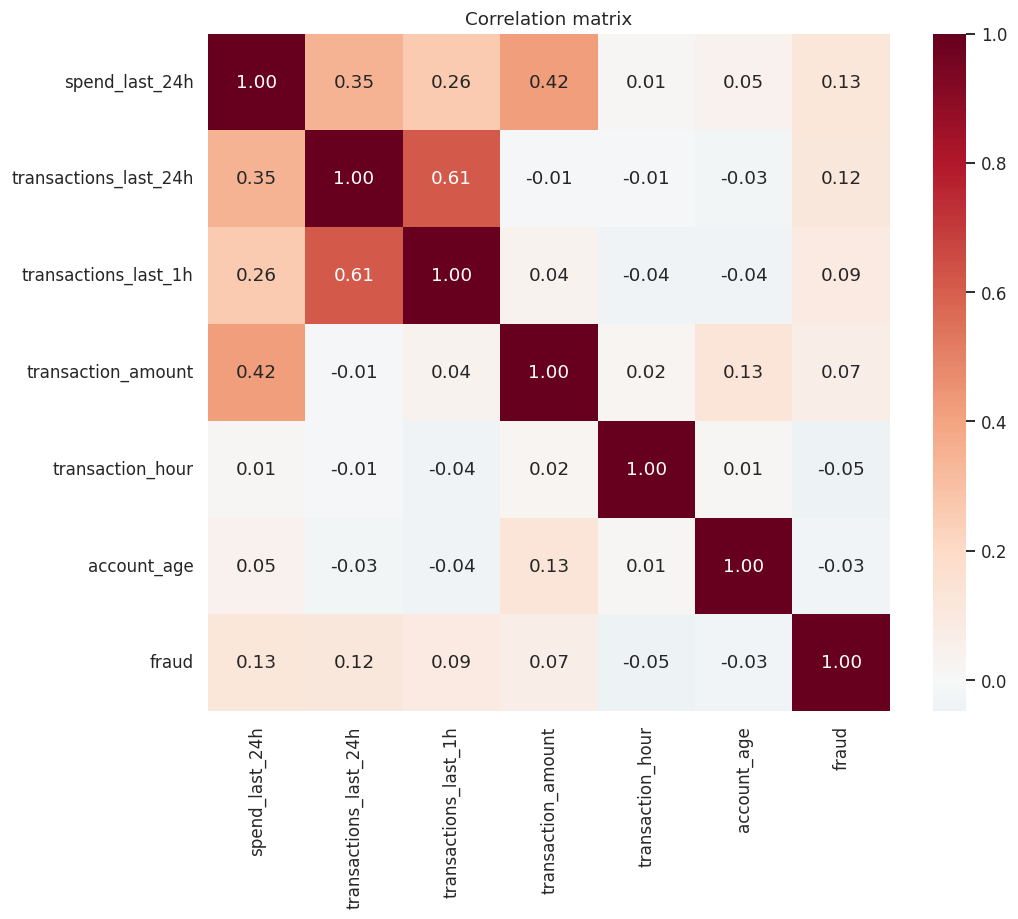

In [9]:
if HOUR_COL or TIME_COL:
    if HOUR_COL:
        hour = eda[HOUR_COL]
    elif TIME_KIND == 'datetime':
        hour = pd.to_datetime(eda[TIME_COL], errors='coerce').dt.hour
    else:
        hour = (pd.to_numeric(eda[TIME_COL]) * (3600 if TIME_UNIT == 'hours' else 1) // 3600) % 24
    fig, ax1 = plt.subplots(figsize=(11, 3.8))
    g = eda.groupby(hour)[TARGET].agg(['mean', 'size'])
    ax1.bar(g.index, g['size'], alpha=.3); ax1.set_ylabel('# transactions'); ax1.set_xlabel('hour of day')
    ax2 = ax1.twinx(); ax2.plot(g.index, g['mean'], c='#C44E52', marker='o'); ax2.set_ylabel('fraud rate')
    plt.title('Volume (bars) and fraud rate (line) by hour'); plt.show()

if len(top_num) > 1:
    cm = eda[top_num[:15] + [TARGET]].corr()
    plt.figure(figsize=(10, 8)); sns.heatmap(cm, cmap='RdBu_r', center=0, annot=len(cm) <= 12, fmt='.2f')
    plt.title('Correlation matrix'); plt.show()

**Insight:** _fill in: time-of-day effect (night hours?) and redundant features._

### 3b. Missing-value audit (train vs test)
If values are missing **more often in test than in train**, missing-value indicator features learned on train can misfire on test. We compare the missing rates and check whether missingness itself predicts fraud before deciding `USE_MISSING_FLAGS`.

In [10]:
feat_cols = [c for c in train_raw.columns if c not in {TARGET, ID_COL}]
rows = []
for c in feat_cols:
    miss = train_raw[c].isna()
    rows.append({'column': c,
                 'train_missing_%': round(100 * miss.mean(), 2),
                 'test_missing_%': round(100 * test_raw[c].isna().mean(), 2) if test_raw is not None and c in test_raw else np.nan,
                 'fraud_rate_if_missing_%': round(100 * train_raw.loc[miss, TARGET].mean(), 2) if miss.any() else np.nan,
                 'fraud_rate_if_present_%': round(100 * train_raw.loc[~miss, TARGET].mean(), 2)})
miss_tab = pd.DataFrame(rows).set_index('column')
display(miss_tab)
print(f'USE_MISSING_FLAGS = {USE_MISSING_FLAGS}. Turn it on only if missing rows have a clearly different fraud rate '
      'AND the train/test missing rates are similar.')

,train_missing_%,test_missing_%,fraud_rate_if_missing_%,fraud_rate_if_present_%
column,,,,
transaction_amount,0.00,0.00,NaN,1.40
transaction_hour,0.00,0.00,NaN,1.40
merchant_category,0.55,2.16,0.0,1.41
country,0.80,2.23,0.0,1.41
transaction_channel,0.50,2.37,0.0,1.41
transactions_last_24h,0.80,2.44,0.0,1.41
spend_last_24h,0.75,2.22,0.0,1.41
account_age,0.50,2.20,0.0,1.41
new_device,0.85,2.44,0.0,1.41


USE_MISSING_FLAGS = False. Turn it on only if missing rows have a clearly different fraud rate AND the train/test missing rates are similar.


**Insight:** _fill in: is missingness informative, and does test have more of it than train?_

### 3c. Point-in-time audit of the window features
`transactions_last_1h`, `transactions_last_24h` and `spend_last_24h` are the most valuable behavioural signals, but only if they use information **available before** the fraud decision. A high correlation is not proof of leakage. What matters is how the column was built, so we check its internal consistency here and state our assumption.

In [11]:
checks = []
t1, t24, s24 = (train_raw[c] if c else None for c in (TX_1H_COL, TX_24H_COL, SPEND_24H_COL))
a_ = train_raw[AMOUNT_COL] if AMOUNT_COL else None
if t1 is not None and t24 is not None:
    checks.append(('rows with 1h count > 24h count (should be 0)', int((t1 > t24).sum())))
if t24 is not None:
    checks.append(('minimum 24h count (1 suggests the current transaction is included)', t24.min()))
if s24 is not None and a_ is not None:
    checks.append(('share of rows where 24h spend < current amount (suggests spend excludes it)', f'{(s24 < a_).mean():.1%}'))
if checks:
    display(pd.DataFrame(checks, columns=['check', 'result']).set_index('check'))
else:
    print('No window features configured.')

,result
check,
rows with 1h count > 24h count (should be 0),0
minimum 24h count (1 suggests the current transaction is included),1.0
share of rows where 24h spend < current amount (suggests spend excludes it),18.1%


**Assumption (to confirm with the organisers):** the window features are computed from transactions **up to and including** the current one, never from later ones. The evidence above is consistent with this: the 24h count is never below 1, and the 1h count never exceeds the 24h count. The 24h spend appears to *exclude* the current amount, since it is often smaller than it, so `amount_vs_avg_24h` compares the transaction with the customer's *recent* spending. If these columns included future activity, they would leak the label and the private-test scores would drop.

## 4. Cleaning & train/test shift
* **Duplicates:** only repeated **transaction IDs** are removed. Identical-looking rows are kept, because fraudsters can repeat the same transaction and those rows are real signal.
* Constant columns and near-unique text columns (hashes, free text) are dropped.
* Missing values are filled inside `build_features` with **training-fold** medians.
* Outliers are **kept**: in fraud the extreme values are often the signal, and tree models are not affected by monotone scaling.

In [12]:
train_df = train_raw
if ID_COL:
    dup_ids = train_df[ID_COL].duplicated().sum()
    train_df = train_df.drop_duplicates(subset=[ID_COL]).reset_index(drop=True)
    print(f'Removed {dup_ids} rows with a repeated {ID_COL}')
print(f'Identical rows (excluding id) kept: {train_df.drop(columns=[c for c in [ID_COL] if c]).duplicated().sum()}')

protected = {TARGET, ID_COL, TIME_COL, AMOUNT_COL, *ENTITY_COLS}
const_cols = [c for c in train_df.columns if c not in protected and train_df[c].nunique(dropna=False) <= 1]
text_cols  = [c for c in train_df.columns if c not in protected and not pd.api.types.is_numeric_dtype(train_df[c])
              and train_df[c].nunique() > 0.5 * len(train_df)]
DROP_COLS = const_cols + text_cols
print('Dropping constant columns:', const_cols, '| near-unique text columns:', text_cols)

y_all = train_df[TARGET].values
CFG = dict(target=TARGET, id_col=ID_COL, time_col=TIME_COL, time_kind=TIME_KIND, time_unit=TIME_UNIT,
           amount_col=AMOUNT_COL, entity_cols=ENTITY_COLS, drop_cols=DROP_COLS,
           hour_col=HOUR_COL, tx_1h_col=TX_1H_COL, tx_24h_col=TX_24H_COL, spend_24h_col=SPEND_24H_COL,
           account_age_col=ACCOUNT_AGE_COL, new_device_col=NEW_DEVICE_COL, channel_col=CHANNEL_COL,
           use_missing_flags=USE_MISSING_FLAGS, onehot_max=ONEHOT_MAX)

Removed 0 rows with a repeated id
Identical rows (excluding id) kept: 0
Dropping constant columns: [] | near-unique text columns: []


### 4b. Adversarial validation: does the test set look like the training set?
We train a classifier to tell **train rows from test rows**. A ROC-AUC near **0.5** means the two are indistinguishable, so validation scores should carry over to the test set. A high AUC means a shift, and its top features show where it is.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

if test_raw is not None:
    cols = [c for c in train_df.columns if c in test_raw.columns and c not in {ID_COL, *DROP_COLS}]
    both = pd.concat([train_df[cols], test_raw[cols]], ignore_index=True)
    both['n_missing'] = both.isna().sum(axis=1)
    for c in both.columns:
        if not pd.api.types.is_numeric_dtype(both[c]):
            both[c] = both[c].astype(str).astype('category')
    is_test = np.r_[np.zeros(len(train_df)), np.ones(len(test_raw))]
    adv = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=SEED, verbose=-1)
    p_adv = cross_val_predict(adv, both, is_test, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                              method='predict_proba')[:, 1]
    ADV_AUC = roc_auc_score(is_test, p_adv)
    adv.fit(both, is_test)
    imp = pd.Series(adv.feature_importances_, index=both.columns).sort_values(ascending=False)
    print(f'Adversarial ROC-AUC (train vs test): {ADV_AUC:.3f}  (0.5 = no detectable shift)')
    display(imp.head(10).to_frame('importance'))

    # where exactly do train and test differ?
    num_shift = [c for c in cols if pd.api.types.is_numeric_dtype(train_df[c]) and train_df[c].nunique() > 2]
    q = pd.DataFrame({c: {'train p10': train_df[c].quantile(.1), 'test p10': test_raw[c].quantile(.1),
                          'train median': train_df[c].median(), 'test median': test_raw[c].median(),
                          'train p90': train_df[c].quantile(.9), 'test p90': test_raw[c].quantile(.9)} for c in num_shift}).T
    display(q.round(2))
    rate_cols = [c for c in cols if c not in num_shift and pd.api.types.is_numeric_dtype(train_df[c])]
    if rate_cols:
        display(pd.DataFrame({'train mean': train_df[rate_cols].mean(), 'test mean': test_raw[rate_cols].mean()}).round(3))
else:
    print('No test file, skipping adversarial validation.')

Adversarial ROC-AUC (train vs test): 0.652  (0.5 = no detectable shift)


,importance
account_age,1373
spend_last_24h,1218
transaction_amount,1192
transaction_hour,726
transactions_last_24h,508
transactions_last_1h,295
merchant_category,244
country,145
n_missing,121
new_device,99


,train p10,test p10,train median,test median,train p90,test p90
transaction_amount,16.66,17.96,70.98,87.74,465.12,1706.77
transaction_hour,2.00,2.00,12.00,12.00,21.00,21.00
transactions_last_24h,2.00,2.00,4.00,4.00,7.00,7.00
spend_last_24h,46.70,54.11,220.08,289.02,1278.52,1625.12
account_age,70.00,98.00,773.00,1158.00,2406.10,3250.00
transactions_last_1h,0.00,0.00,1.00,1.00,2.00,2.00


,train mean,test mean
new_device,0.082,0.154


**Insight:** _fill in: the adversarial AUC and what drives it._ When we ran it, test transactions were **larger** (90th-percentile amount ~3× train's), accounts were **older**, `new_device` was more common, and missing values were ~4× as frequent. Consequences:
* Relative features (`amount_vs_avg_24h`, `amount_share_24h`, `burst_ratio`) should transfer better than absolute amounts.
* The private-test fraud rate may differ from 1.8%, so calibrated probabilities and the F1 threshold may shift. The **ranking** (PR-AUC) is the most robust part.

## 5. Feature engineering
Fraud is *behavioural*: a transaction is suspicious **relative to what is normal**. `build_features` creates these features, each only when its columns exist:

| Group | Features | Intuition |
|---|---|---|
| Amount | raw, `log1p`, round-amount flag | fraud skews to unusual or round values |
| Hour | `hour_sin`, `hour_cos`, `is_night` | cyclical, so 23:00 and 00:00 are neighbours; fraud clusters at night |
| Recent behaviour | `avg_spend_24h`, `amount_vs_avg_24h`, `amount_share_24h` | "is this amount unusual compared with the last 24h?" |
| Velocity | `burst_ratio = tx_1h / (tx_24h + 1)` | a sudden burst of activity in the last hour |
| Account | `account_age_log`, `new_account` (< 30 days) | new accounts are riskier |
| Device | `new_device × log(amount)`, `new_device × channel` | a new device plus a large or remote payment |
| Categoricals | one-hot (≤ 30 levels), frequency encoding above | no arbitrary integer ordering |
| Entities (when ids exist) | leave-one-out mean amount, counts, velocity | "is this normal **for this card**?" |

All statistics are **learned on training rows only** (`state`) and re-applied to validation and test rows. The same cell is reused in `predict_colab.ipynb`, together with the calibration and decision helpers.

In [14]:
# ============================================================================================
# SHARED INFERENCE CODE: feature engineering, calibration, decision rule.
# This exact cell is copied into predict_colab.ipynb, so keep the two in sync.
# ============================================================================================
FE_VERSION = '2.0'

def _safe_name(c):
    return re.sub(r'[^0-9a-zA-Z_]+', '_', str(c)).strip('_')

def _time_numeric(s, kind, unit):
    """Return (seconds as float, datetime series or None)."""
    if kind == 'datetime':
        t = pd.to_datetime(s, errors='coerce')
        return (t - pd.Timestamp('1970-01-01')).dt.total_seconds(), t
    t = pd.to_numeric(s, errors='coerce').astype(float)
    return t * (3600.0 if unit == 'hours' else 1.0), None

def _num(df, name):
    """Column as float, or None when it is not configured / not present."""
    if name and name in df.columns:
        return pd.to_numeric(df[name], errors='coerce').astype(float)
    return None

def _as_cat(s):
    """Categorical column as strings, with missing values as an explicit token."""
    return s.astype(object).where(s.notna(), '__missing__').astype(str)

def build_features(df, state=None, cfg=None):
    """Raw transactions -> numeric model matrix.

    state=None : FIT mode. Learns encodings / medians / statistics from `df` (training rows only!).
    state=dict : TRANSFORM mode. Re-uses what was learned; never looks at labels.
    Returns (X, state).
    """
    fit = state is None
    if fit:
        state = {'version': FE_VERSION, 'cfg': dict(cfg)}
    cfg = state['cfg']
    tgt, idc   = cfg.get('target'), cfg.get('id_col')
    tc, tk, tu = cfg.get('time_col'), cfg.get('time_kind'), cfg.get('time_unit') or 'seconds'
    amt, ents  = cfg.get('amount_col'), list(cfg.get('entity_cols') or [])
    dropped    = set(cfg.get('drop_cols') or [])
    flags      = bool(cfg.get('use_missing_flags'))
    onehot_max = int(cfg.get('onehot_max', 30))

    df  = df.reset_index(drop=True)
    out = pd.DataFrame(index=df.index)
    reserved = {c for c in [tgt, idc, tc, amt] if c} | set(ents) | dropped

    # ---- 1. Amount ---------------------------------------------------------------------
    a = _num(df, amt)
    if a is not None:
        out['amount'] = a
        out['amount_log'] = np.log1p(a.clip(lower=0))
        out['amount_is_round'] = (a.round(0) == a).astype(float)

    # ---- 2. Hour of day (cyclical: 23:00 and 00:00 are neighbours) ----------------------
    h = _num(df, cfg.get('hour_col'))
    tsec = None
    if tc and tc in df.columns:            # a real timestamp column gives the hour too
        tsec, tdt = _time_numeric(df[tc], tk, tu)
        if h is None:
            h = tdt.dt.hour.astype(float) if tdt is not None else (tsec // 3600) % 24
        out['dayofweek'] = tdt.dt.dayofweek if tdt is not None else (tsec // 86400) % 7
    if h is not None:
        out['hour_sin'] = np.sin(2 * np.pi * h / 24)
        out['hour_cos'] = np.cos(2 * np.pi * h / 24)
        out['is_night'] = h.between(0, 5).astype(float).where(h.notna())
        if not (cfg.get('hour_col') and cfg['hour_col'] in df.columns):
            out['hour'] = h

    # ---- 3. Behaviour from the dataset's own window features ---------------------------
    tx1, tx24 = _num(df, cfg.get('tx_1h_col')), _num(df, cfg.get('tx_24h_col'))
    sp24, age = _num(df, cfg.get('spend_24h_col')), _num(df, cfg.get('account_age_col'))
    nd = _num(df, cfg.get('new_device_col'))
    if sp24 is not None and tx24 is not None:
        avg = sp24 / tx24.clip(lower=1)
        out['avg_spend_24h'] = avg
        if a is not None:
            out['amount_vs_avg_24h'] = a / (avg + 1)        # "16x this customer's usual size"
    if sp24 is not None and a is not None:
        out['amount_share_24h'] = a / (sp24 + a + 1e-6)
    if tx1 is not None and tx24 is not None:
        out['burst_ratio'] = tx1 / (tx24 + 1)              # share of the day's activity in the last hour
    if age is not None:
        out['account_age_log'] = np.log1p(age.clip(lower=0))
        out['new_account'] = (age < 30).astype(float).where(age.notna())
    if nd is not None:
        if a is not None:
            out['new_device_x_amount_log'] = nd * np.log1p(a.clip(lower=0))
        ch = cfg.get('channel_col')
        if ch and ch in df.columns:
            s = _as_cat(df[ch])
            if fit:
                state['channel_levels'] = [v for v in s.value_counts().index if v != '__missing__'][:onehot_max]
            for lvl in state.get('channel_levels', []):
                out[f'new_device_x_{_safe_name(lvl)}'] = nd * (s == lvl).astype(float)

    # ---- 4. Entity behaviour (only when card / customer / merchant ids exist) ----------
    for e in ents:
        if e not in df.columns:
            continue
        key, n = df[e].astype(str), _safe_name(e)
        if fit:
            state[f'cnt_{e}'] = key.value_counts()
            if a is not None:
                g = a.groupby(key)
                state[f'agg_{e}'] = pd.DataFrame({'sum': g.sum(), 'n': g.count(), 'std': g.std(), 'max': g.max()})
        cnt = key.map(state[f'cnt_{e}']).fillna(0).values
        out[f'{n}_txn_count'] = cnt + (0 if fit else 1)     # train count includes the row itself
        if a is not None:
            agg = state[f'agg_{e}']
            s_, n_ = key.map(agg['sum']).values, key.map(agg['n']).values
            # leave-one-out mean on training rows so a row never sees its own amount
            mean = (s_ - a.values) / np.where(n_ - 1 > 0, n_ - 1, np.nan) if fit else s_ / n_
            sd = key.map(agg['std']).values
            out[f'{n}_amt_mean'] = mean
            out[f'amt_over_{n}_mean'] = a.values / (mean + 1e-6)
            out[f'amt_z_{n}'] = (a.values - mean) / (sd + 1e-6)
        if tsec is not None:
            cur = pd.DataFrame({'k': key.values, 't': tsec.values, 'cur': True, 'pos': np.arange(len(df))})
            if fit:
                state[f'hist_{e}'] = cur[['k', 't']].copy()
                both = cur
            else:
                both = pd.concat([state[f'hist_{e}'].assign(cur=False, pos=-1), cur], ignore_index=True)
            both = both.sort_values(['k', 't'], kind='mergesort')
            both['dt_prev'] = both.groupby('k')['t'].diff()
            both['n_prev'] = both.groupby('k').cumcount()
            both = both[both['cur']].sort_values('pos')
            out[f'{n}_secs_since_prev'] = both['dt_prev'].values
            out[f'{n}_n_prev_txn'] = both['n_prev'].values

    # ---- 5. Remaining raw columns: numerics pass through, categoricals encoded ----------
    if fit:
        rest = [c for c in df.columns if c not in reserved]
        num = [c for c in rest if pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c])]
        cat = [c for c in rest if c not in num]
        state['num_cols'] = num
        state['missing_flag_cols'] = [c for c in rest if df[c].isna().mean() > 0.001] if flags else []
        state['cat_levels'], state['cat_freq'] = {}, {}
        for c in cat:
            s = _as_cat(df[c])
            vc = s[s != '__missing__'].value_counts()
            state['cat_freq'][c] = vc / max(len(df), 1)
            if len(vc) <= onehot_max:
                state['cat_levels'][c] = list(vc.index)
    for c in state['num_cols']:
        out[_safe_name(c)] = pd.to_numeric(df[c], errors='coerce').astype(float) if c in df.columns else np.nan
    for c in state['missing_flag_cols']:
        out[f'{_safe_name(c)}_isna'] = df[c].isna().astype(float) if c in df.columns else 1.0
    for c, freq in state['cat_freq'].items():
        s = _as_cat(df[c]) if c in df.columns else pd.Series(['__missing__'] * len(df))
        n = _safe_name(c)
        if c in state['cat_levels']:                 # low cardinality -> one-hot, no fake ordering
            for lvl in state['cat_levels'][c]:
                out[f'{n}__{_safe_name(lvl)}'] = (s == lvl).astype(float).values
        else:                                        # high cardinality -> frequency only
            out[f'{n}_freq'] = s.map(freq).values    # missing / unseen -> NaN -> median

    # ---- 6. Finalise: same columns, same order, no NaN/inf -----------------------------
    out.columns = [_safe_name(c) for c in out.columns]
    out = out.loc[:, ~out.columns.duplicated()]
    out = out.replace([np.inf, -np.inf], np.nan).astype(float)
    if fit:
        state['feature_cols'] = list(out.columns)
        state['fill'] = out.median().fillna(0)
    out = out.reindex(columns=state['feature_cols']).fillna(state['fill'])
    return out, state

def apply_calibration(cal, p):
    """Map raw model scores to calibrated fraud probabilities."""
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    if cal is None or cal['method'] == 'none':
        return p
    if cal['method'] == 'isotonic':
        return cal['model'].predict(p)
    return cal['model'].predict_proba(np.log(p / (1 - p)).reshape(-1, 1))[:, 1]

def decide(p, df, rule):
    """Turn calibrated probabilities into 0/1 flags.
    'f1' / 'f2': one probability threshold.  'cost': flag when expected loss > review cost."""
    if rule['strategy'] == 'cost':
        amt = pd.to_numeric(df[rule['amount_col']], errors='coerce').fillna(rule['amount_fill']).values
        return (p * amt * rule['cost_fn_factor'] > rule['cost_fp']).astype(int)
    return (p >= rule['threshold']).astype(int)

print('shared inference code ready, FE version', FE_VERSION)

shared inference code ready, FE version 2.0


In [15]:
_X_demo, _st_demo = build_features(train_df, cfg=CFG)
print(f'{_X_demo.shape[1]} features:', _X_demo.columns.tolist())
_X_demo.describe().T.head(40)

48 features: ['amount', 'amount_log', 'amount_is_round', 'hour_sin', 'hour_cos', 'is_night', 'avg_spend_24h', 'amount_vs_avg_24h', 'amount_share_24h', 'burst_ratio', 'account_age_log', 'new_account', 'new_device_x_amount_log', 'new_device_x_card_present', 'new_device_x_ecommerce', 'new_device_x_mobile_app', 'new_device_x_bank_transfer', 'transaction_hour', 'transactions_last_24h', 'spend_last_24h', 'account_age', 'new_device', 'transactions_last_1h', 'merchant_category__grocery', 'merchant_category__retail', 'merchant_category__transport', 'merchant_category__food_delivery', 'merchant_category__entertainment', 'merchant_category__utilities', 'merchant_category__cash_transfer', 'merchant_category__electronics', 'merchant_category__gaming', 'merchant_category__travel', 'merchant_category__luxury', 'country__SG', 'country__MY', 'country__ID', 'country__US', 'country__TH', 'country__PH', 'country__GB', 'country__AU', 'country__VN', 'country__JP', 'transaction_channel__card_present', 'trans

,count,mean,std,min,25%,50%,75%,max
amount,2000.0,233.252135,579.229780,2.500000,31.790000,7.098000e+01,189.262500,5898.400000
amount_log,2000.0,4.421344,1.310834,1.252763,3.490121,4.276388e+00,5.248404,8.682606
amount_is_round,2000.0,0.009500,0.097028,0.000000,0.000000,0.000000e+00,0.000000,1.000000
hour_sin,2000.0,-0.002550,0.705279,-1.000000,-0.707107,0.000000e+00,0.707107,1.000000
hour_cos,2000.0,-0.003145,0.709271,-1.000000,-0.707107,-6.123234e-17,0.707107,1.000000
is_night,2000.0,0.246500,0.431081,0.000000,0.000000,0.000000e+00,0.000000,1.000000
avg_spend_24h,2000.0,114.175736,271.325234,0.000000,23.758750,4.862708e+01,119.553000,8079.140000
amount_vs_avg_24h,2000.0,5.492419,32.022514,0.012075,0.745594,1.428291e+00,2.744906,913.240000
amount_share_24h,2000.0,0.308258,0.224029,0.005017,0.137049,2.495907e-01,0.429305,1.000000
burst_ratio,2000.0,0.147806,0.154627,0.000000,0.000000,1.428571e-01,0.250000,0.750000


## 6. Validation design (no data is used twice)

```
all labelled rows ──► 20% HOLD-OUT (locked away, used once in section 10)
        │
        └─► 80% DEVELOPMENT ──► 5 stratified folds
                                 for each fold: fit features on 4/5 → transform 1/5 → train → predict
                                 = one out-of-fold (OOF) prediction for every development row
              used for: model comparison · Optuna tuning · calibration · threshold
```
* Features are fitted **inside each fold**, so a validation row never influences its own encodings or medians.
* With only ~280 development frauds, OOF predictions use every one of them for evaluation, instead of a single ~70-fraud validation set that is easy to over-fit by trying many models and thresholds.
* If the data has a real timestamp, the hold-out is the **latest** 20% and the folds respect time order.

In [16]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit

def make_folds(frame, y, n=N_FOLDS):
    if TIME_COL:
        order = np.argsort(_time_numeric(frame[TIME_COL], TIME_KIND, TIME_UNIT)[0].fillna(0).values, kind='mergesort')
        return [(order[a], order[b]) for a, b in TimeSeriesSplit(n_splits=n).split(order)]
    return list(StratifiedKFold(n_splits=n, shuffle=True, random_state=SEED).split(frame, y))

def build_fold_cache(frame, y, folds):
    """Features fitted inside every fold. Built once and reused by every model and Optuna trial."""
    cache = []
    for tr, va in folds:
        Xa, st = build_features(frame.iloc[tr], cfg=CFG)
        Xb, _ = build_features(frame.iloc[va], state=st)
        cache.append((Xa, y[tr], Xb, y[va], va))
    return cache

# ---- lock away the hold-out ----
idx = np.arange(len(train_df))
if TIME_COL:
    order = np.argsort(_time_numeric(train_df[TIME_COL], TIME_KIND, TIME_UNIT)[0].fillna(0).values, kind='mergesort')
    cut = int(len(order) * (1 - HOLDOUT_FRAC)); dev_idx, hold_idx = np.sort(order[:cut]), np.sort(order[cut:])
else:
    dev_idx, hold_idx = train_test_split(idx, test_size=HOLDOUT_FRAC, stratify=y_all, random_state=SEED)
dev_df, hold_df = train_df.iloc[dev_idx].reset_index(drop=True), train_df.iloc[hold_idx].reset_index(drop=True)
y_dev, y_hold = y_all[dev_idx], y_all[hold_idx]

t0 = time.time()
dev_folds = make_folds(dev_df, y_dev)
dev_cache = build_fold_cache(dev_df, y_dev, dev_folds)
print(f'development: {len(dev_df):,} rows, {y_dev.sum()} fraud | hold-out (locked): {len(hold_df):,} rows, {y_hold.sum()} fraud')
print(f'{len(dev_cache)} folds cached in {time.time()-t0:.1f}s | features per fold: {dev_cache[0][0].shape[1]}')

development: 1,600 rows, 22 fraud | hold-out (locked): 400 rows, 6 fraud
5 folds cached in 1.7s | features per fold: 48


In [17]:
# Feature sanity flag (fold 0 training part). A single feature that almost perfectly ranks fraud deserves
# a closer look at HOW it was built, but a high score alone is not proof of leakage (see section 3c).
from sklearn.metrics import average_precision_score
Xa0, ya0 = dev_cache[0][0], dev_cache[0][1]
solo = pd.Series({c: max(average_precision_score(ya0, Xa0[c]), average_precision_score(ya0, -Xa0[c])) for c in Xa0.columns})
display(solo.sort_values(ascending=False).head(12).to_frame('single-feature PR-AUC'))
flag = solo[solo > 0.9]
print('Review how these were built:' if len(flag) else 'No single feature is suspiciously predictive.', list(flag.index))

,single-feature PR-AUC
transactions_last_1h,0.101226
spend_last_24h,0.081615
transactions_last_24h,0.064093
new_device_x_amount_log,0.052696
amount_log,0.051068
amount,0.051068
new_device_x_ecommerce,0.042684
merchant_category__luxury,0.038715
avg_spend_24h,0.037310
new_device,0.028243


No single feature is suspiciously predictive. []


## 7. Model comparison on out-of-fold predictions
| Model | Why it is a candidate | Imbalance handling |
|---|---|---|
| Dummy (prior) | the floor: PR-AUC = fraud rate | none |
| Logistic regression | simple, interpretable linear baseline | `class_weight='balanced'` |
| Random forest | bagged trees, non-linear, few assumptions | `class_weight='balanced_subsample'` |
| XGBoost (GPU) | gradient boosting: strong on tabular data, handles interactions | `scale_pos_weight = √(#neg/#pos)` |
| LightGBM | fast leaf-wise boosting | `scale_pos_weight` |
| CatBoost (GPU) | ordered boosting, robust defaults | `auto_class_weights='SqrtBalanced'` |
| LightGBM + SMOTE *(optional)* | re-sampling vs re-weighting; synthetic rows can be unrealistic (e.g. `new_device = 0.47`) and skew probabilities | SMOTE inside the training folds only |

Class weights are softened (√ratio): the full ratio lets a few hundred frauds dominate and inflates scores. Tuning searches the whole range, and calibration (section 9) corrects the probabilities afterwards.

In [18]:
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score, confusion_matrix, \
    classification_report, brier_score_loss, log_loss
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SPW = float((y_dev == 0).sum() / max((y_dev == 1).sum(), 1))
SPW_SOFT = max(np.sqrt(SPW), 1.0)
XGB_DEVICE = 'cuda' if GPU else 'cpu'
print(f'#neg/#pos = {SPW:.1f} | default scale_pos_weight = {SPW_SOFT:.1f} | XGBoost device = {XGB_DEVICE}')

def make_xgb(**kw):
    p = dict(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8,
             min_child_weight=5, scale_pos_weight=SPW_SOFT, eval_metric='aucpr', tree_method='hist',
             device=XGB_DEVICE, random_state=SEED, n_jobs=-1)
    p.update(kw); return XGBClassifier(**p)

def make_lgbm(**kw):
    p = dict(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.8,
             subsample_freq=1, colsample_bytree=0.8, scale_pos_weight=SPW_SOFT, random_state=SEED,
             n_jobs=-1, verbose=-1)
    p.update(kw); return LGBMClassifier(**p)

def best_threshold(y, p, beta=1.0):
    prec, rec, thr = precision_recall_curve(y, p)
    prec, rec = prec[:-1], rec[:-1]
    f = (1 + beta**2) * prec * rec / np.clip(beta**2 * prec + rec, 1e-12, None)
    i = int(np.nanargmax(f))
    return float(thr[i]), float(f[i])

def score(y, p, yhat=None):
    """Threshold-free metrics + F1/Recall/Precision (at the best-F1 threshold when no decisions are given)."""
    if yhat is None:
        yhat = (p >= best_threshold(y, p)[0]).astype(int)
    return {'PR_AUC': average_precision_score(y, p), 'ROC_AUC': roc_auc_score(y, p),
            'F1': f1_score(y, yhat), 'Recall': recall_score(y, yhat),
            'Precision': precision_score(y, yhat, zero_division=0)}

def cv_oof(factory, cache, n_rows):
    """Out-of-fold predictions: every row is predicted by a model that never saw it."""
    oof, fold_ap, t = np.full(n_rows, np.nan), [], time.time()
    for Xa, ya, Xb, yb, vb in cache:
        m = factory(); m.fit(Xa, ya)
        p = m.predict_proba(Xb)[:, 1]; oof[vb] = p
        if yb.sum() > 0: fold_ap.append(average_precision_score(yb, p))
    return oof, fold_ap, time.time() - t

factories, results, oofs = {}, [], {}
def evaluate(name, factory):
    oof, fold_ap, secs = cv_oof(factory, dev_cache, len(dev_df))
    m = ~np.isnan(oof)
    r = {'model': name, **score(y_dev[m], oof[m]), 'PR_AUC_fold_mean': np.mean(fold_ap),
         'PR_AUC_fold_std': np.std(fold_ap), 'sec': round(secs, 1)}
    factories[name], oofs[name] = factory, oof; results.append(r)
    print(f"{name:<22} OOF PR-AUC={r['PR_AUC']:.4f} (folds {r['PR_AUC_fold_mean']:.4f} ± {r['PR_AUC_fold_std']:.4f})"
          f"  best-F1={r['F1']:.4f}  Recall={r['Recall']:.4f}  ({secs:.1f}s)")

evaluate('Dummy (prior)', lambda: DummyClassifier(strategy='prior'))
evaluate('LogReg (balanced)', lambda: make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=3000, C=0.5)))
evaluate('RandomForest', lambda: RandomForestClassifier(n_estimators=400, min_samples_leaf=3, class_weight='balanced_subsample',
                                                         n_jobs=-1, random_state=SEED))
evaluate('XGBoost', lambda: make_xgb())
evaluate('LightGBM', lambda: make_lgbm())
if USE_CATBOOST:
    try:
        from catboost import CatBoostClassifier
        evaluate('CatBoost', lambda: CatBoostClassifier(iterations=800, learning_rate=0.05, depth=6,
                 auto_class_weights='SqrtBalanced', task_type='GPU' if GPU else 'CPU', random_seed=SEED,
                 verbose=0, allow_writing_files=False))
    except ImportError:
        print('catboost not installed, skipping')
if TRY_SMOTE:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    evaluate('LightGBM + SMOTE', lambda: ImbPipeline([('smote', SMOTE(sampling_strategy=0.2, random_state=SEED)),
                                                      ('clf', make_lgbm(scale_pos_weight=1.0))]))

#neg/#pos = 71.7 | default scale_pos_weight = 8.5 | XGBoost device = cuda
Dummy (prior)          OOF PR-AUC=0.0131 (folds 0.0138 ± 0.0015)  best-F1=0.0271  Recall=1.0000  (0.0s)
LogReg (balanced)      OOF PR-AUC=0.0338 (folds 0.0597 ± 0.0365)  best-F1=0.1239  Recall=0.3182  (0.8s)
RandomForest           OOF PR-AUC=0.0978 (folds 0.1472 ± 0.0734)  best-F1=0.2353  Recall=0.2727  (8.1s)
XGBoost                OOF PR-AUC=0.0742 (folds 0.1167 ± 0.0824)  best-F1=0.1556  Recall=0.3182  (3.0s)
LightGBM               OOF PR-AUC=0.0638 (folds 0.0748 ± 0.0371)  best-F1=0.1724  Recall=0.2273  (3.3s)
CatBoost               OOF PR-AUC=0.0596 (folds 0.0815 ± 0.0450)  best-F1=0.1613  Recall=0.2273  (127.3s)


,PR_AUC,ROC_AUC,F1,Recall,Precision,PR_AUC_fold_mean,PR_AUC_fold_std,sec
model,,,,,,,,
RandomForest,0.0978,0.7500,0.2353,0.2727,0.2069,0.1472,0.0734,8.100000
XGBoost,0.0742,0.6346,0.1556,0.3182,0.1029,0.1167,0.0824,3.000000
LightGBM,0.0638,0.6210,0.1724,0.2273,0.1389,0.0748,0.0371,3.300000
CatBoost,0.0596,0.6287,0.1613,0.2273,0.1250,0.0815,0.0450,127.300000
LogReg (balanced),0.0338,0.5855,0.1239,0.3182,0.0769,0.0597,0.0365,0.800000
Dummy (prior),0.0131,0.4723,0.0271,1.0000,0.0138,0.0138,0.0015,0.000000


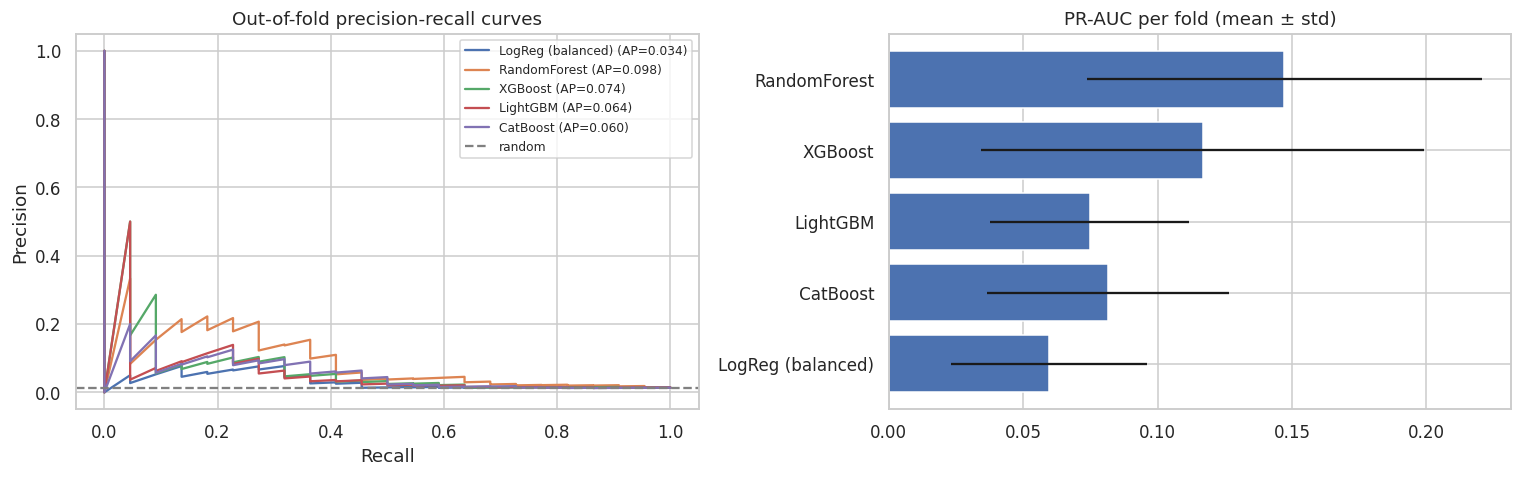

In [19]:
res = pd.DataFrame(results).set_index('model').sort_values('PR_AUC', ascending=False)
display(res.style.format({c: '{:.4f}' for c in ['PR_AUC', 'ROC_AUC', 'F1', 'Recall', 'Precision', 'PR_AUC_fold_mean', 'PR_AUC_fold_std']})
           .background_gradient(subset=['PR_AUC', 'F1', 'Recall'], cmap='Greens'))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for name, p in oofs.items():
    if name.startswith('Dummy'): continue
    m = ~np.isnan(p); pr, rc, _ = precision_recall_curve(y_dev[m], p[m])
    ax[0].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_dev[m], p[m]):.3f})")
ax[0].axhline(y_dev.mean(), ls='--', c='grey', label='random'); ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Out-of-fold precision-recall curves'); ax[0].legend(fontsize=8)
r2 = res.drop(index=[i for i in res.index if i.startswith('Dummy')])
ax[1].barh(r2.index, r2['PR_AUC_fold_mean'], xerr=r2['PR_AUC_fold_std'], color='#4C72B0')
ax[1].set_title('PR-AUC per fold (mean ± std)'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Insight:** _fill in: which family wins, and whether the gap is bigger than the fold-to-fold spread (if not, prefer the simpler model)._

## 8. Hyper-parameter tuning (Optuna)
We tune the best booster with Bayesian optimisation (TPE), maximising **mean fold PR-AUC on the cached development folds**. The hold-out is still untouched.
* **Early stopping uses an inner 15% slice of each fold's training part**, never the fold being scored, so the tuning score is not inflated.
* `scale_pos_weight` is searched from 1 (no re-weighting) to #neg/#pos (full re-weighting).
* The default configuration is trial 0, as a reference point.

In [20]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE = next(m for m in res.index if m in ('XGBoost', 'LightGBM'))
make_model = make_xgb if TUNE == 'XGBoost' else make_lgbm
print('Tuning:', TUNE)

def suggest(trial):
    common = dict(learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                  subsample=trial.suggest_float('subsample', 0.5, 1.0),
                  colsample_bytree=trial.suggest_float('colsample_bytree', 0.4, 1.0),
                  reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                  reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                  scale_pos_weight=trial.suggest_float('scale_pos_weight', 1, max(SPW, 1.01), log=True))
    if TUNE == 'XGBoost':
        return dict(common, max_depth=trial.suggest_int('max_depth', 2, 8),
                    min_child_weight=trial.suggest_float('min_child_weight', 1, 30, log=True),
                    gamma=trial.suggest_float('gamma', 0, 5))
    return dict(common, num_leaves=trial.suggest_int('num_leaves', 7, 127, log=True),
                min_child_samples=trial.suggest_int('min_child_samples', 10, 300, log=True))

MAX_TREES, PATIENCE, ES_FRAC = 3000, 100, 0.15

def fit_early_stop(params, Xa, ya):
    """Fit with early stopping on an inner slice of the TRAINING part; returns (model, best #trees)."""
    if TIME_COL:
        cut = int(len(Xa) * (1 - ES_FRAC)); i_fit, i_es = np.arange(cut), np.arange(cut, len(Xa))
    else:
        i_fit, i_es = train_test_split(np.arange(len(Xa)), test_size=ES_FRAC, stratify=ya, random_state=SEED)
    Xf, yf, Xe, ye = Xa.iloc[i_fit], ya[i_fit], Xa.iloc[i_es], ya[i_es]
    if TUNE == 'XGBoost':
        m = make_xgb(**params, n_estimators=MAX_TREES, early_stopping_rounds=PATIENCE)
        m.fit(Xf, yf, eval_set=[(Xe, ye)], verbose=False)
        return m, m.best_iteration + 1
    import lightgbm as lgb
    m = make_lgbm(**params, n_estimators=MAX_TREES)
    m.fit(Xf, yf, eval_set=[(Xe, ye)], eval_metric='average_precision',
          callbacks=[lgb.early_stopping(PATIENCE, verbose=False)])
    return m, max(m.best_iteration_, 1)

def objective(trial):
    params, scores, iters = suggest(trial), [], []
    for k, (Xa, ya, Xb, yb, _) in enumerate(dev_cache):
        if yb.sum() == 0: continue
        m, n = fit_early_stop(params, Xa, ya)
        scores.append(average_precision_score(yb, m.predict_proba(Xb)[:, 1])); iters.append(n)
        trial.report(float(np.mean(scores)), k)
        if trial.should_prune(): raise optuna.TrialPruned()
    trial.set_user_attr('n_estimators', int(np.mean(iters) / (1 - ES_FRAC)))   # refit sees ~15% more rows
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=8))
default = dict(learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, reg_alpha=1e-3,
               scale_pos_weight=SPW_SOFT)
default.update(dict(max_depth=5, min_child_weight=5, gamma=0.0) if TUNE == 'XGBoost' else dict(num_leaves=31, min_child_samples=50))
study.enqueue_trial(default)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT, show_progress_bar=False)
BEST_PARAMS = {**study.best_params, 'n_estimators': study.best_trial.user_attrs['n_estimators']}
print(f'{len(study.trials)} trials in {time.time()-t0:.0f}s | best mean fold PR-AUC = {study.best_value:.4f}')
print('Best params:', BEST_PARAMS)

Tuning: XGBoost
10 trials in 15s | best mean fold PR-AUC = 0.1805
Best params: {'learning_rate': 0.08341106432362087, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9819459112971965, 'reg_lambda': 2.1368329072358767, 'reg_alpha': 0.0070689749506246055, 'scale_pos_weight': 2.1747520068295487, 'max_depth': 3, 'min_child_weight': 2.8145092716060645, 'gamma': 2.6237821581611893, 'n_estimators': 78}


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

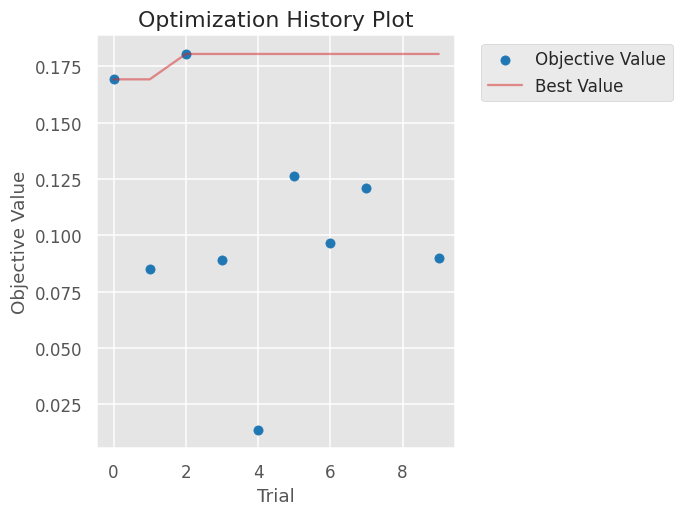

<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

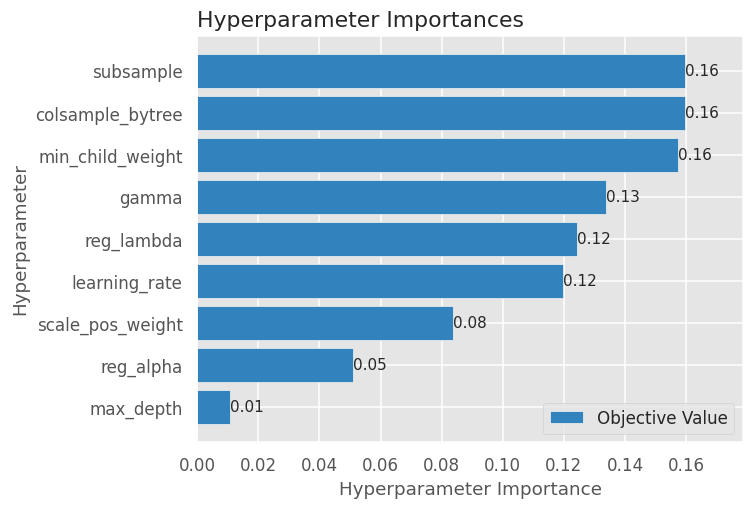

XGBoost (tuned)        OOF PR-AUC=0.0849 (folds 0.1221 ± 0.0385)  best-F1=0.2439  Recall=0.2273  (0.5s)

Selected model: RandomForest  (OOF PR-AUC 0.0978, folds 0.1472 ± 0.0734)


In [21]:
try:
    display(optuna.visualization.matplotlib.plot_optimization_history(study)); plt.show()
    display(optuna.visualization.matplotlib.plot_param_importances(study)); plt.show()
except Exception as e:
    print('plot skipped:', e)

evaluate(f'{TUNE} (tuned)', lambda: make_model(**BEST_PARAMS))

# model selection on OUT-OF-FOLD PR-AUC only; the hold-out plays no part
res = pd.DataFrame(results).set_index('model').sort_values('PR_AUC', ascending=False)
BEST_NAME = res.index[0]
BEST_FACTORY = factories[BEST_NAME]
print(f'\nSelected model: {BEST_NAME}  (OOF PR-AUC {res.loc[BEST_NAME, "PR_AUC"]:.4f}, '
      f'folds {res.loc[BEST_NAME, "PR_AUC_fold_mean"]:.4f} ± {res.loc[BEST_NAME, "PR_AUC_fold_std"]:.4f})')

## 9. Calibration & decision threshold (learned on development OOF predictions)
**Why calibrate?** Class weights deliberately make the model care more about fraud, which pushes its scores up. A raw score of 0.76 does **not** mean a 76% chance of fraud. Calibration fits a mapping from score to observed fraud rate:
* **Sigmoid / Platt** (default): a 2-parameter logistic curve. Robust with only ~280 frauds.
* **Isotonic**: a flexible step function. Needs more positives and can over-fit.

Calibration is monotonic, so the **ranking and PR-AUC barely change**. What changes is the meaning of the number. The threshold is chosen **after** calibration, on the same OOF predictions:
* **F1-optimal** (default): F1 is a scored metric.
* **F2-optimal**: recall counts twice as much.
* **Cost-based** (section 12): flag when *P(fraud) × amount × loss share > review cost*.

Calibration: sigmoid | F1 threshold 0.0443 | F2 threshold 0.0384 | using 'f1'


,PR_AUC,ROC_AUC,F1,Recall,Precision
0.5,0.0978,0.7500,0.0000,0.0000,0.0000
F1-opt (0.044),0.0978,0.7500,0.2353,0.2727,0.2069
F2-opt (0.038),0.0978,0.7500,0.2162,0.3636,0.1538


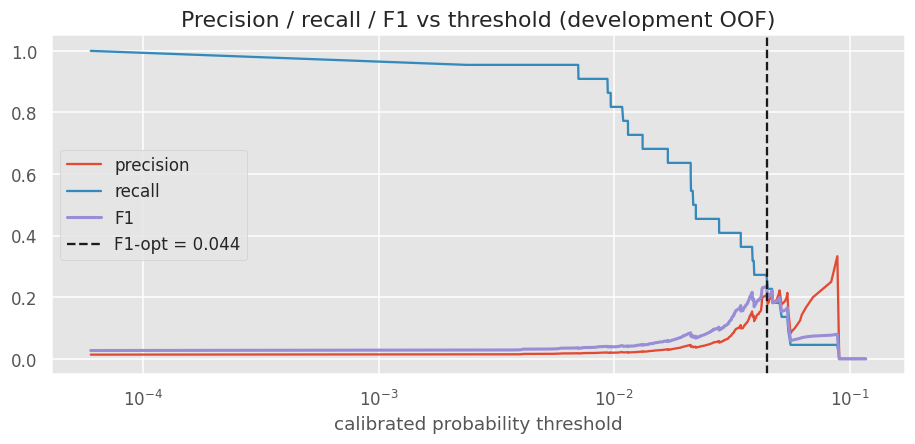

In [22]:
def fit_calibrator(p, y, method=CALIBRATION):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    if method == 'none':
        return {'method': 'none'}
    if method == 'isotonic':
        from sklearn.isotonic import IsotonicRegression
        return {'method': 'isotonic', 'model': IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(p, y)}
    return {'method': 'sigmoid', 'model': LogisticRegression(C=1e4, max_iter=1000).fit(np.log(p / (1 - p)).reshape(-1, 1), y)}

def make_rule(y, p_cal, strategy=THRESHOLD_STRATEGY):
    thr_f1, _ = best_threshold(y, p_cal, beta=1)
    thr_f2, _ = best_threshold(y, p_cal, beta=2)
    if strategy == 'cost' and not AMOUNT_COL:
        print('No amount column, so the cost rule is unavailable; using F1.'); strategy = 'f1'
    return {'strategy': strategy, 'threshold': thr_f1 if strategy != 'f2' else thr_f2,
            'thr_f1': thr_f1, 'thr_f2': thr_f2, 'amount_col': AMOUNT_COL,
            'amount_fill': float(train_df[AMOUNT_COL].median()) if AMOUNT_COL else 0.0,
            'cost_fn_factor': COST_FN_FACTOR, 'cost_fp': COST_FP}

oof_raw = oofs[BEST_NAME]; m = ~np.isnan(oof_raw)
CAL_DEV = fit_calibrator(oof_raw[m], y_dev[m])
oof_cal = np.full(len(oof_raw), np.nan); oof_cal[m] = apply_calibration(CAL_DEV, oof_raw[m])
RULE_DEV = make_rule(y_dev[m], oof_cal[m])
print(f"Calibration: {CAL_DEV['method']} | F1 threshold {RULE_DEV['thr_f1']:.4f} | F2 threshold {RULE_DEV['thr_f2']:.4f} "
      f"| using '{RULE_DEV['strategy']}'")

comp = pd.DataFrame({k: score(y_dev[m], oof_cal[m], (oof_cal[m] >= t).astype(int)) for k, t in
                     {'0.5': 0.5, f"F1-opt ({RULE_DEV['thr_f1']:.3f})": RULE_DEV['thr_f1'],
                      f"F2-opt ({RULE_DEV['thr_f2']:.3f})": RULE_DEV['thr_f2']}.items()}).T
display(comp.style.format('{:.4f}'))

prec, rec, thr = precision_recall_curve(y_dev[m], oof_cal[m])
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
plt.figure(figsize=(10, 4))
plt.plot(thr, prec[:-1], label='precision'); plt.plot(thr, rec[:-1], label='recall'); plt.plot(thr, f1s, label='F1', lw=2)
plt.axvline(RULE_DEV['thr_f1'], c='k', ls='--', label=f"F1-opt = {RULE_DEV['thr_f1']:.3f}")
plt.xlabel('calibrated probability threshold'); plt.xscale('log'); plt.legend()
plt.title('Precision / recall / F1 vs threshold (development OOF)'); plt.show()

**Insight:** _fill in: how flat the F1 curve is near its peak. A flat peak means the threshold is robust to a different fraud rate in the private test._

## 10. Hold-out report (the only time the hold-out is used)
We replay the whole recipe exactly as it will run in production: fit features and the selected model on the full development set, apply the calibrator and threshold learned in section 9, and score the 20% hold-out **once**. If the hold-out numbers are close to the OOF numbers, our validation is honest.

In [23]:
X_dev, fe_dev = build_features(dev_df, cfg=CFG)
X_hold, _ = build_features(hold_df, state=fe_dev)
hold_model = BEST_FACTORY().fit(X_dev, y_dev)
p_hold_raw = hold_model.predict_proba(X_hold)[:, 1]
p_hold = apply_calibration(CAL_DEV, p_hold_raw)
yhat_hold = decide(p_hold, hold_df, RULE_DEV)

def full_report(y, p, yhat):
    return {**score(y, p, yhat), 'Brier': brier_score_loss(y, p), 'LogLoss': log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))}

report = pd.DataFrame({
    'Development OOF (5-fold)': full_report(y_dev[m], oof_cal[m], decide(oof_cal[m], dev_df[m], RULE_DEV)),
    'Hold-out (used once)':     full_report(y_hold, p_hold, yhat_hold)}).T
display(report.style.format('{:.4f}'))
print('Note: the OOF row uses the calibrator and threshold fitted on those same OOF predictions, so it is slightly optimistic; the hold-out row is not.')

,PR_AUC,ROC_AUC,F1,Recall,Precision,Brier,LogLoss
Development OOF (5-fold),0.0978,0.7500,0.2353,0.2727,0.2069,0.0133,0.0683
Hold-out (used once),0.0233,0.3875,0.0000,0.0000,0.0000,0.0150,0.1054


Note: the OOF row uses the calibrator and threshold fitted on those same OOF predictions, so it is slightly optimistic; the hold-out row is not.


**Insight:** _fill in: is the hold-out PR-AUC within the fold-to-fold spread of section 7? If yes, the validation is trustworthy._

### 10b. How much does one hold-out swing?
With ~70 frauds, a single hold-out score is noisy: a few hard frauds landing in it can halve PR-AUC. Here the **same recipe** (selected model, fixed parameters) is re-run on several different random 80/20 splits. Nothing is chosen from this; it only shows the spread. The parameters were tuned on rows that overlap these splits, so treat the mean as slightly optimistic.

In [24]:
REPEATS = 5
if TIME_COL:
    print('Time-ordered data: a random re-split would leak the future, skipping.')
else:
    rows = []
    for seed in range(REPEATS):
        i_d, i_h = train_test_split(np.arange(len(train_df)), test_size=HOLDOUT_FRAC, stratify=y_all, random_state=100 + seed)
        Xd, st = build_features(train_df.iloc[i_d], cfg=CFG)
        Xh, _ = build_features(train_df.iloc[i_h], state=st)
        p = BEST_FACTORY().fit(Xd, y_all[i_d]).predict_proba(Xh)[:, 1]
        rows.append({'split seed': 100 + seed, 'hold-out frauds': int(y_all[i_h].sum()),
                     'PR_AUC': average_precision_score(y_all[i_h], p), 'ROC_AUC': roc_auc_score(y_all[i_h], p)})
    rep = pd.DataFrame(rows).set_index('split seed')
    display(rep.style.format({'PR_AUC': '{:.4f}', 'ROC_AUC': '{:.4f}'}))
    print(f"PR-AUC over {REPEATS} splits: {rep.PR_AUC.mean():.4f} ± {rep.PR_AUC.std():.4f} "
          f"(section 10 hold-out: {report.loc['Hold-out (used once)', 'PR_AUC']:.4f})")

,hold-out frauds,PR_AUC,ROC_AUC
split seed,,,
100,6,0.1135,0.6662
101,6,0.0286,0.4973
102,6,0.0911,0.7111
103,6,0.1960,0.8164
104,6,0.0703,0.7635


PR-AUC over 5 splits: 0.0999 ± 0.0622 (section 10 hold-out: 0.0233)


## 11. Calibration check (on the hold-out)
If the model is calibrated, then among transactions given about a 20% probability, about 20% should really be fraud. We compare raw scores with calibrated probabilities using the **Brier score** and **log loss** (lower is better), a **reliability curve** and a table of probability bands.

,Brier,LogLoss,mean prediction,actual fraud rate
raw score,0.0170,0.1405,0.0315,0.0150
calibrated,0.0150,0.1054,0.0134,0.0150


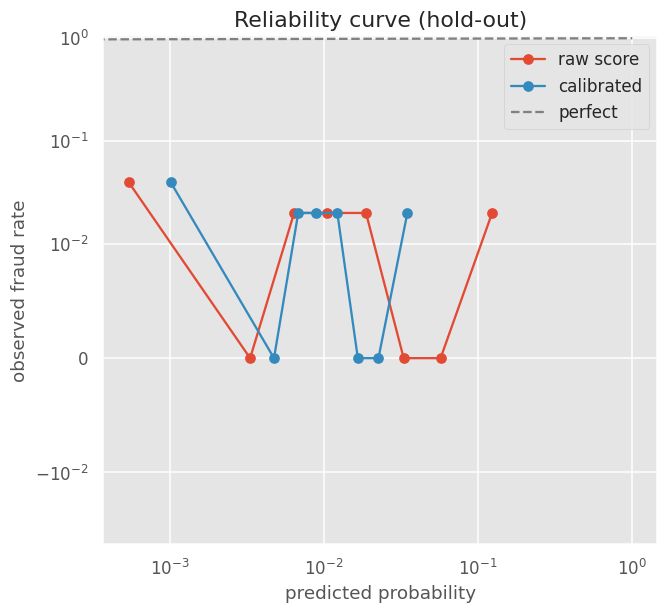

,transactions,mean predicted %,observed fraud %,frauds
"[0.0, 0.01)",197,0.53,2.03,4
"[0.01, 0.02)",110,1.46,0.91,1
"[0.02, 0.05)",90,2.82,1.11,1
"[0.05, 0.1)",3,6.17,0.00,0
"[0.1, 0.2)",0,NaN,NaN,0
"[0.2, 0.4)",0,NaN,NaN,0
"[0.4, 0.6)",0,NaN,NaN,0
"[0.6, 1.0)",0,NaN,NaN,0


With ~70 hold-out frauds, the upper bands hold few transactions, so expect noise there.


In [25]:
from sklearn.calibration import calibration_curve

cal_tab = pd.DataFrame({'raw score': {'Brier': brier_score_loss(y_hold, p_hold_raw), 'LogLoss': log_loss(y_hold, np.clip(p_hold_raw, 1e-6, 1-1e-6)),
                                      'mean prediction': p_hold_raw.mean()},
                        'calibrated': {'Brier': brier_score_loss(y_hold, p_hold), 'LogLoss': log_loss(y_hold, np.clip(p_hold, 1e-6, 1-1e-6)),
                                       'mean prediction': p_hold.mean()}}).T
cal_tab['actual fraud rate'] = y_hold.mean()
display(cal_tab.style.format('{:.4f}'))

fig, ax = plt.subplots(figsize=(6.5, 6))
for name, p in [('raw score', p_hold_raw), ('calibrated', p_hold)]:
    fy, fx = calibration_curve(y_hold, p, n_bins=8, strategy='quantile')
    ax.plot(fx, fy, marker='o', label=name)
ax.plot([0, 1], [0, 1], ls='--', c='grey', label='perfect')
ax.set_xscale('log'); ax.set_yscale('symlog', linthresh=0.01); ax.set_xlabel('predicted probability'); ax.set_ylabel('observed fraud rate')
ax.set_title('Reliability curve (hold-out)'); ax.legend(); plt.show()

bands = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 1.0001]
b = pd.cut(p_hold, bands, right=False)
band_tab = pd.DataFrame({'transactions': pd.Series(y_hold).groupby(b, observed=False).size(),
                         'mean predicted %': (pd.Series(p_hold).groupby(b, observed=False).mean() * 100).round(2),
                         'observed fraud %': (pd.Series(y_hold).groupby(b, observed=False).mean() * 100).round(2),
                         'frauds': pd.Series(y_hold).groupby(b, observed=False).sum()})
display(band_tab)
print('With ~70 hold-out frauds, the upper bands hold few transactions, so expect noise there.')

**Insight:** _fill in: does the calibrated column track the observed fraud rate? How inflated were the raw scores?_

## 12. Business view: alert capacity and cost
F1 treats a missed fraud and a false alarm as equally bad. A bank does not: a missed \$2,000 fraud costs far more than a \$5 review. Two more practical views:
* **Capacity:** if reviewers can only check *K* transactions, what share of fraud do the top *K* catch (Precision@K, Recall@K)?
* **Expected cost:** flag a transaction when **P(fraud) × amount × `COST_FN_FACTOR` > `COST_FP`**, so a large transaction is flagged at a lower probability than a small one. This needs calibrated probabilities.

The submission uses `THRESHOLD_STRATEGY` (default **F1**, because F1 and Recall are scored). This section shows what the cost rule would change.

In [26]:
order = np.argsort(-p_hold)
cap = []
for K in [25, 50, 100, 200, 400]:
    if K > len(order): break
    tp = y_hold[order[:K]].sum()
    cap.append({'K reviewed': K, 'share of traffic': f'{K/len(order):.1%}', 'frauds caught': int(tp),
                'Precision@K': tp / K, 'Recall@K': tp / max(y_hold.sum(), 1)})
display(pd.DataFrame(cap).set_index('K reviewed').style.format({'Precision@K': '{:.3f}', 'Recall@K': '{:.3f}'}))

if AMOUNT_COL:
    amt_hold = pd.to_numeric(hold_df[AMOUNT_COL], errors='coerce').fillna(RULE_DEV['amount_fill']).values
    def total_cost(flags):
        missed = (y_hold == 1) & (flags == 0)
        return {'flagged': int(flags.sum()), 'frauds caught': int(((y_hold == 1) & (flags == 1)).sum()),
                'fraud loss ($)': float((amt_hold[missed] * COST_FN_FACTOR).sum()),
                'review cost ($)': float(flags.sum() * COST_FP)}
    rules = {'flag nothing': np.zeros(len(y_hold), int),
             f"F1 threshold ({RULE_DEV['thr_f1']:.3f})": (p_hold >= RULE_DEV['thr_f1']).astype(int),
             'cost rule': decide(p_hold, hold_df, {**RULE_DEV, 'strategy': 'cost'})}
    cost_tab = pd.DataFrame({k: total_cost(v) for k, v in rules.items()}).T
    cost_tab['total cost ($)'] = cost_tab['fraud loss ($)'] + cost_tab['review cost ($)']
    display(cost_tab.style.format({c: '{:,.0f}' for c in cost_tab.columns}))
    print(f'Assumptions: a missed fraud loses {COST_FN_FACTOR:.0%} of its amount; each flag costs ${COST_FP:.0f} to review.')

,share of traffic,frauds caught,Precision@K,Recall@K
K reviewed,,,,
25,6.2%,1,0.040,0.167
50,12.5%,1,0.020,0.167
100,25.0%,1,0.010,0.167
200,50.0%,2,0.010,0.333
400,100.0%,6,0.015,1.000


,flagged,frauds caught,fraud loss ($),review cost ($),total cost ($)
flag nothing,0,0,867,0,867
F1 threshold (0.044),6,0,867,30,897
cost rule,66,1,520,330,850


Assumptions: a missed fraud loses 100% of its amount; each flag costs $5 to review.


**Insight:** _fill in: how many reviews catch most of the fraud, and whether the cost rule beats the F1 rule in dollars._

## 13. Interpretation (hold-out model)

              precision    recall  f1-score   support

       legit     0.9848    0.9848    0.9848       394
       fraud     0.0000    0.0000    0.0000         6

    accuracy                         0.9700       400
   macro avg     0.4924    0.4924    0.4924       400
weighted avg     0.9700    0.9700    0.9700       400



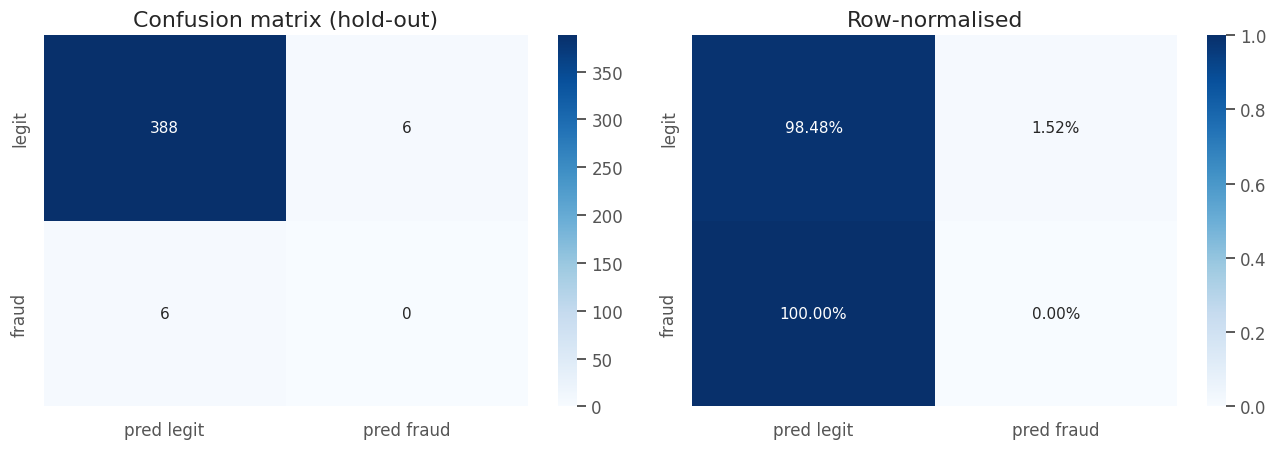

Caught 0/6 frauds (0.0%); 6 legitimate customers flagged (1.52% of legitimate traffic).


In [27]:
print(classification_report(y_hold, yhat_hold, target_names=['legit', 'fraud'], digits=4))
cm = confusion_matrix(y_hold, yhat_hold)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax[0], xticklabels=['pred legit', 'pred fraud'], yticklabels=['legit', 'fraud'])
ax[0].set_title('Confusion matrix (hold-out)')
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt='.2%', cmap='Blues', ax=ax[1],
            xticklabels=['pred legit', 'pred fraud'], yticklabels=['legit', 'fraud'])
ax[1].set_title('Row-normalised'); plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'Caught {tp}/{tp+fn} frauds ({tp/max(tp+fn,1):.1%}); {fp} legitimate customers flagged ({fp/max(fp+tn,1):.2%} of legitimate traffic).')

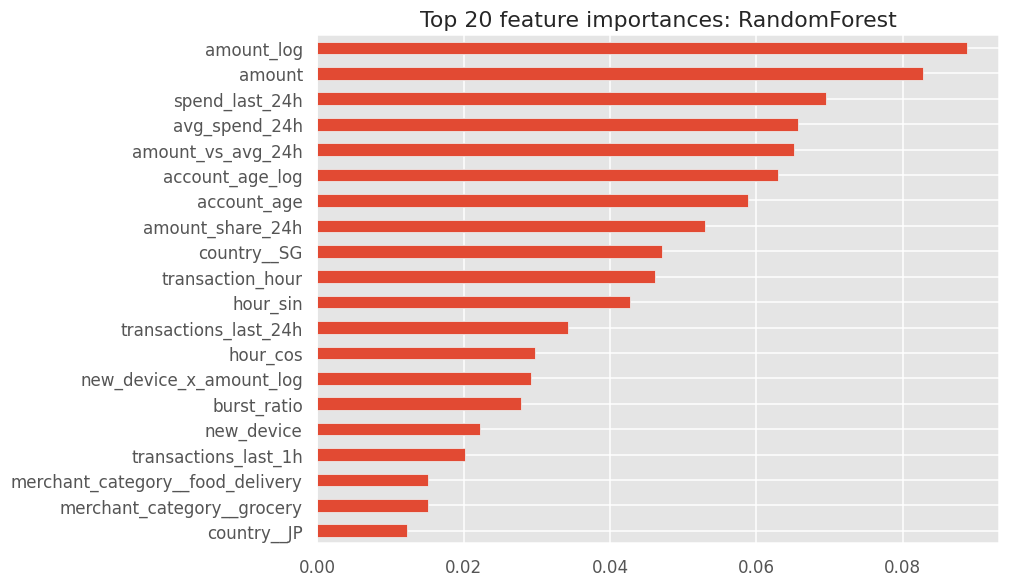

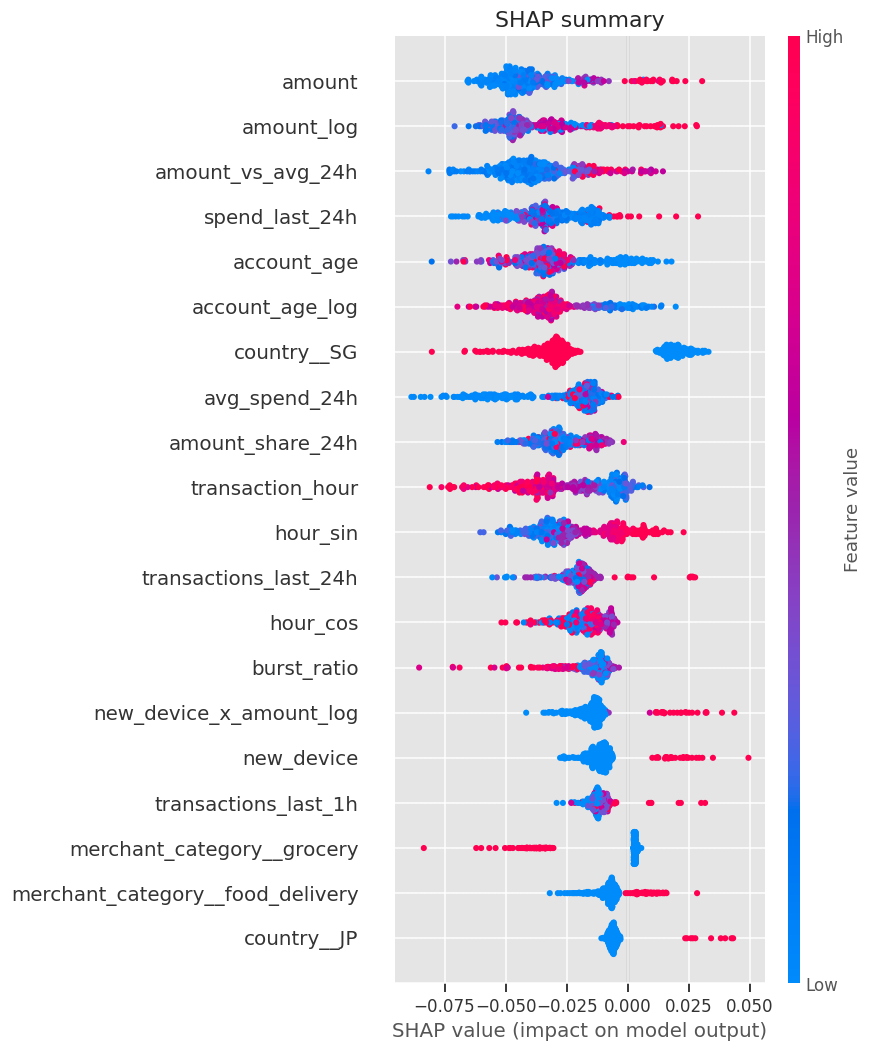

In [28]:
est = hold_model.steps[-1][1] if hasattr(hold_model, 'steps') else hold_model
if hasattr(est, 'feature_importances_'):
    imp = pd.Series(est.feature_importances_, index=X_dev.columns).sort_values(ascending=False)
    imp.head(20)[::-1].plot.barh(figsize=(8, 6), title=f'Top 20 feature importances: {BEST_NAME}'); plt.show()
elif hasattr(est, 'coef_'):
    imp = pd.Series(np.abs(est.coef_[0]), index=X_dev.columns).sort_values(ascending=False)
    imp.head(20)[::-1].plot.barh(figsize=(8, 6), title='Top 20 |coefficients|'); plt.show()

try:
    import shap
    sample = X_hold.sample(min(2000, len(X_hold)), random_state=SEED)
    if hasattr(hold_model, 'steps'):
        for _, step in hold_model.steps[:-1]:
            if hasattr(step, 'transform'):
                sample = pd.DataFrame(step.transform(sample), columns=X_hold.columns)
    try:
        sv = shap.TreeExplainer(est).shap_values(sample)
    except Exception:
        sv = shap.LinearExplainer(est, sample).shap_values(sample)
    if isinstance(sv, list): sv = sv[1]
    if getattr(sv, 'ndim', 2) == 3: sv = sv[:, :, 1]
    shap.summary_plot(sv, sample, max_display=20, show=False); plt.title('SHAP summary'); plt.show()
except Exception as e:
    print('SHAP skipped:', e)

**Insight:** _fill in: the top drivers (e.g. `amount_vs_avg_24h`, `burst_ratio`, `new_device`) and whether they make business sense._

In [29]:
view = hold_df.copy(); view['fraud_probability'] = p_hold; view['flagged'] = yhat_hold
fn_rows = view[(view[TARGET] == 1) & (view.flagged == 0)].sort_values('fraud_probability')
fp_rows = view[(view[TARGET] == 0) & (view.flagged == 1)].sort_values('fraud_probability', ascending=False)
print(f'Missed fraud: {len(fn_rows)}'); display(fn_rows.head(8))
print(f'False alarms: {len(fp_rows)}'); display(fp_rows.head(8))

Missed fraud: 6


,id,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h,fraud,fraud_probability,flagged
14,FR016681,62.05,13,food_delivery,SG,mobile_app,4.0,199.47,118.0,0.0,0.0,1,0.000060,0
47,FR017170,39.13,18,grocery,SG,card_present,2.0,16.08,243.0,0.0,1.0,1,0.000060,0
68,FR019962,347.74,1,travel,SG,card_present,2.0,1442.01,1894.0,0.0,1.0,1,0.006983,0
270,FR014802,3.58,16,transport,SG,card_present,5.0,87.32,116.0,0.0,0.0,1,0.008359,0
244,FR011364,67.15,3,grocery,GB,bank_transfer,1.0,0.00,753.0,0.0,0.0,1,0.012968,0
314,FR019853,347.25,2,electronics,US,bank_transfer,20.0,5780.05,2561.0,0.0,4.0,1,0.038355,0


False alarms: 6


,id,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h,fraud,fraud_probability,flagged
345,FR000017,174.28,7,utilities,TH,ecommerce,4.0,374.94,98.0,1.0,0.0,0,0.062546,1
285,FR012984,31.19,4,grocery,PH,ecommerce,5.0,162.16,33.0,1.0,0.0,0,0.061757,1
236,FR000548,1947.64,0,luxury,JP,ecommerce,23.0,3241.86,3289.0,0.0,2.0,0,0.060886,1
136,FR011954,515.12,15,luxury,SG,ecommerce,8.0,6555.88,52.0,0.0,2.0,0,0.045784,1
97,FR013837,413.53,11,cash_transfer,SG,bank_transfer,2.0,132.23,46.0,1.0,0.0,0,0.045136,1
257,FR017099,3447.58,12,luxury,JP,card_present,4.0,1746.22,1387.0,0.0,1.0,0,0.044328,1


**Insight:** _fill in: patterns in the errors, and the features that could fix them._

## 14. Assumptions & limitations

**Assumptions of the gradient-boosted tree model**
* Rows are roughly independent, and the test data come from the **same distribution** as training. Section 4b checks this, apart from the missing-value shift.
* Labels are correct. In practice, fraud labels arrive late and some fraud is never reported.
* The window features use only information available at decision time (section 3c). This is the most important assumption to confirm.
* No linearity, normality or scaling assumptions. Interactions are learned by tree splits.
* Raw scores are risk *rankings*; only after calibration are they read as probabilities. Calibration assumes the private test has a similar fraud rate. If the rate differs, the ranking (PR-AUC) still holds, but the probabilities shift.

**Logistic regression baseline:** a linear relationship with the log-odds, independent rows, limited multicollinearity, and scaled inputs.

**Limitations / next steps**
* ~350 frauds in total: every estimate has noticeable variance, so we report fold spread and keep a hold-out.
* Missingness is higher in test than in train, so missing-value flags are off by default.
* A threshold chosen for F1 is not the business-optimal rule (section 12).
* Possible gains: averaging XGBoost, LightGBM and CatBoost; repeated CV; cross-fitted target encoding for high-cardinality categoricals.

## 15. Final model → `model.pkl`
The hold-out has done its job. To use **all** labelled data:
1. Run 5-fold OOF on all rows with the selected model, and **re-fit the calibrator and threshold on these OOF predictions**. The threshold then matches the final model's own score distribution, instead of a smaller earlier model's.
2. Fit features and the model on all rows.
3. Save one bundle: model + calibrator + decision rule + feature state.

In [30]:
t0 = time.time()
all_cache = build_fold_cache(train_df, y_all, make_folds(train_df, y_all))
oof_all, ap_all, _ = cv_oof(BEST_FACTORY, all_cache, len(train_df))
mk = ~np.isnan(oof_all)
CAL = fit_calibrator(oof_all[mk], y_all[mk])
p_all = apply_calibration(CAL, oof_all[mk])
RULE = make_rule(y_all[mk], p_all)
all_oof_metrics = full_report(y_all[mk], p_all, decide(p_all, train_df[mk], RULE))
print(f"All-data OOF: PR-AUC {all_oof_metrics['PR_AUC']:.4f} (folds {np.mean(ap_all):.4f} ± {np.std(ap_all):.4f}) | "
      f"F1 {all_oof_metrics['F1']:.4f} | Recall {all_oof_metrics['Recall']:.4f} | threshold {RULE['threshold']:.4f}")

X_full, fe_state = build_features(train_df, cfg=CFG)
final_model = BEST_FACTORY().fit(X_full, y_all)
print(f'Final fit on {X_full.shape} | total {time.time()-t0:.1f}s')

_est = final_model.steps[-1][1] if hasattr(final_model, 'steps') else final_model
if isinstance(_est, XGBClassifier):
    _est.set_params(device='cpu')        # predict on CPU wherever the pkl is loaded

bundle = {'model': final_model, 'model_name': BEST_NAME, 'calibrator': CAL, 'rule': RULE,
          'fe_state': fe_state, 'feature_cols': fe_state['feature_cols'], 'fe_version': FE_VERSION,
          'submission': {'id_name': SUB_ID_NAME, 'label_name': SUB_LABEL_NAME, 'include_proba': INCLUDE_PROBA_IN_SUBMISSION},
          'metrics': {'dev_oof': report.iloc[0].to_dict(), 'holdout': report.iloc[1].to_dict(), 'all_oof': all_oof_metrics}}
with open('model.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print(f'Saved model.pkl ({os.path.getsize("model.pkl")/1e6:.1f} MB) | {BEST_NAME} | {CAL["method"]} calibration | rule={RULE["strategy"]}')

import sklearn, xgboost, lightgbm, matplotlib
reqs = {'pandas': pd.__version__, 'numpy': np.__version__, 'scikit-learn': sklearn.__version__,
        'xgboost': xgboost.__version__, 'lightgbm': lightgbm.__version__, 'optuna': optuna.__version__,
        'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__}
for pkg, mod in [('catboost', 'catboost'), ('imbalanced-learn', 'imblearn'), ('shap', 'shap')]:
    try: reqs[pkg] = __import__(mod).__version__
    except ImportError: pass
with open('requirements.txt', 'w') as f:
    f.write('\n'.join(f'{k}=={v}' for k, v in reqs.items()) + '\n')
print(open('requirements.txt').read())

All-data OOF: PR-AUC 0.0559 (folds 0.1303 ± 0.1305) | F1 0.1609 | Recall 0.2500 | threshold 0.0394
Final fit on (2000, 48) | total 12.0s
Saved model.pkl (2.8 MB) | RandomForest | sigmoid calibration | rule=f1
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
xgboost==3.4.1
lightgbm==4.6.0
optuna==5.0.0
matplotlib==3.10.0
seaborn==0.13.2
catboost==1.2.10
imbalanced-learn==0.14.2
shap==0.52.0



## 16. Predictions on the test set → `submission.csv`

In [31]:
if test_raw is None:
    print('No test file found, skipping predictions.')
else:
    with open('model.pkl', 'rb') as f:      # reload to prove the saved file works end to end
        B = pickle.load(f)
    X_test, _ = build_features(test_raw, state=B['fe_state'])
    assert list(X_test.columns) == B['feature_cols']
    proba = apply_calibration(B['calibrator'], B['model'].predict_proba(X_test)[:, 1])
    label = decide(proba, test_raw, B['rule'])

    ids = test_raw[ID_COL].values if ID_COL and ID_COL in test_raw.columns else np.arange(len(test_raw))
    s = B['submission']
    sub = pd.DataFrame({s['id_name']: ids, s['label_name']: label})
    if s['include_proba']:
        sub['fraud_probability'] = proba
    sub.to_csv('submission.csv', index=False)
    pd.DataFrame({s['id_name']: ids, 'fraud_probability': proba}).to_csv('submission_proba.csv', index=False)

    assert len(sub) == len(test_raw), 'row count mismatch!'
    print(f'submission.csv: {sub.shape} | flagged {label.mean():.2%} (train fraud rate {train_df[TARGET].mean():.2%}) '
          f'| mean calibrated probability {proba.mean():.2%}')
    display(sub.head())

submission.csv: (12000, 2) | flagged 3.34% (train fraud rate 1.40%) | mean calibrated probability 1.52%


,id,fraud
0,FR021005,0
1,FR030078,0
2,FR020717,0
3,FR026657,0
4,FR023775,0


In [32]:
if IN_COLAB:
    from google.colab import files
    for f in ['model.pkl', 'submission.csv', 'submission_proba.csv', 'requirements.txt']:
        if os.path.exists(f): files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The selected model (RandomForest) is not trained in rounds, so the curves below use a default LightGBM for illustration.
LightGBM (default settings): 400 boosting rounds ("epochs"). Each round flags its riskiest 1.38% of transactions (cut-off from training scores).

Round    1/400 | train: loss 0.0619  acc 0.9862  prec 0.000  PR-AUC 0.079 | test: loss 0.0851  acc 0.9850  prec 0.000  PR-AUC 0.015
Round   31/400 | train: loss 0.0314  acc 0.9975  prec 0.909  PR-AUC 0.934 | test: loss 0.0930  acc 0.9825  prec 0.000  PR-AUC 0.024
Round   72/400 | train: loss 0.0123  acc 1.0000  prec 1.000  PR-AUC 1.000 | test: loss 0.0984  acc 0.9825  prec 0.000  PR-AUC 0.096
Round  113/400 | train: loss 0.0046  acc 1.0000  prec 1.000  PR-AUC 1.000 | test: loss 0.1131  acc 0.9825  prec 0.000  PR-AUC 0.095
Round  154/400 | train: loss 0.0018  acc 1.0000  prec 1.000  PR-AUC 1.000 | test: loss 0.1283  acc 0.9850  prec 0.500  PR-AUC 0.095
Round  195/400 | train: loss 0.0007  acc 1.0000  prec 1.000  PR-AUC 1.000

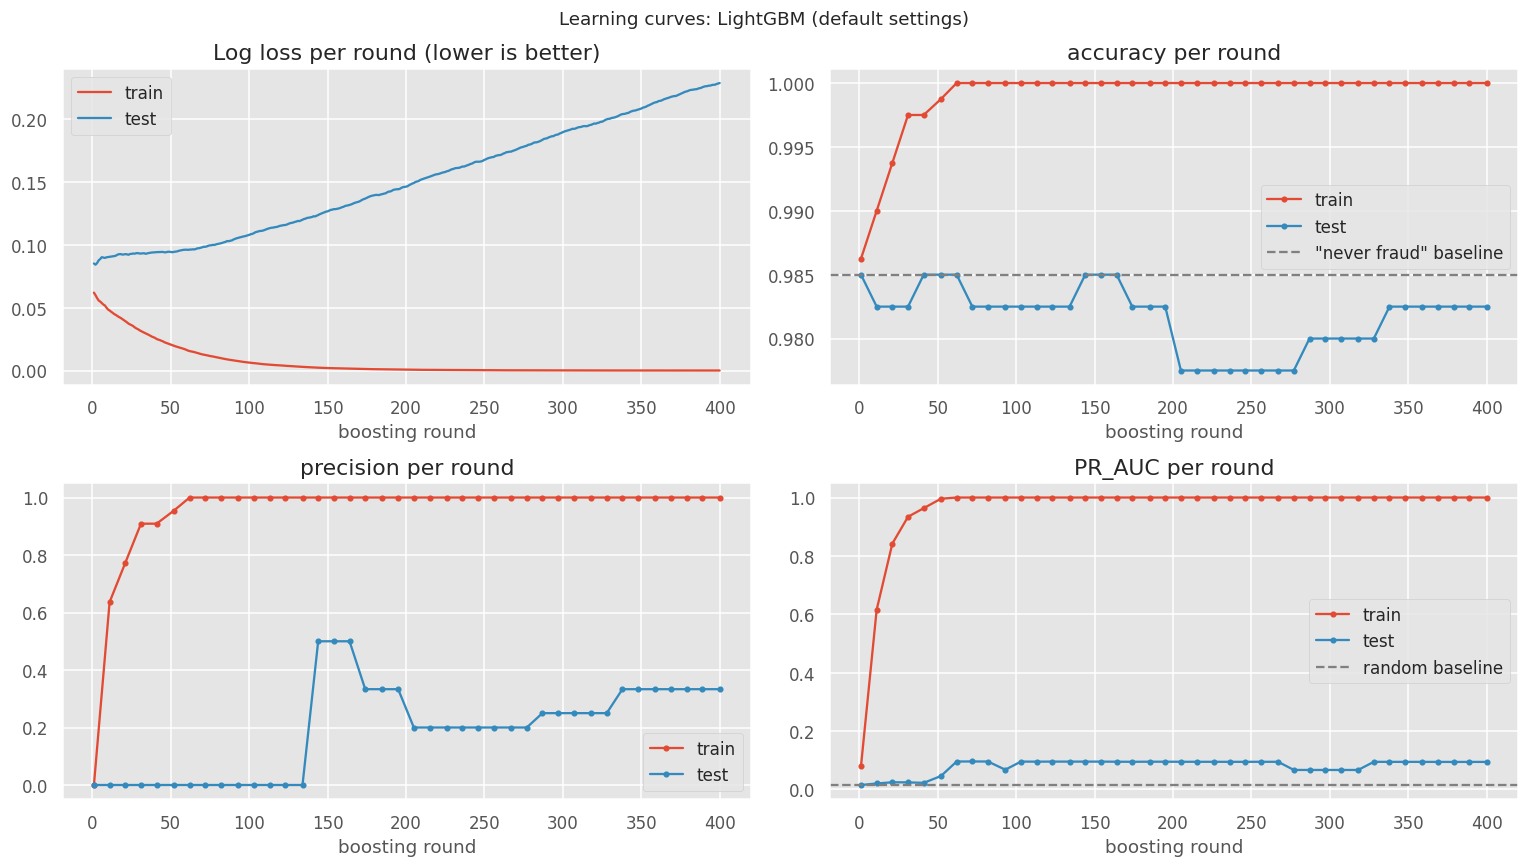

Test loss is lowest at round 2/400. If it rises well after that while train loss keeps falling, the model is over-fitting. (Shown for understanding only; the number of trees was chosen by cross-validation in section 8, not by this hold-out.)


,Accuracy,Precision,Recall,F1,PR_AUC,Frauds,Flagged
Training (80% the model learned from),0.9906,0.5946,1.0000,0.7458,1.0000,22,37
"Test (20% hold-out, never seen)",0.9700,0.0000,0.0000,0.0000,0.0233,6,6


Model: RandomForest | threshold 0.0443 on calibrated probabilities. Accuracy baseline ("never fraud") on test = 0.9850; the gap between training and test shows how much the model memorised its training rows.


In [37]:
# ============================================================================================
# LEARNING CURVES: training vs test, round by round, then final training vs test scores.
# Paste as a NEW cell at the end of fraud_detection_colab.ipynb and run it after "Run all".
#
# Gradient boosting has no epochs: each boosting ROUND adds one tree, so rounds play that role.
# "Test" = the 20% hold-out (the competition test file has no labels). It is only WATCHED here,
# never used to choose anything, so the notebook's honest evaluation is unchanged.
# ============================================================================================
from sklearn.metrics import accuracy_score

est = hold_model.steps[-1][1] if hasattr(hold_model, 'steps') else hold_model
if isinstance(est, (XGBClassifier, LGBMClassifier)):
    curve_name, params = BEST_NAME, est.get_params()
else:
    curve_name, params = 'LightGBM (default settings)', make_lgbm().get_params()
    print(f'The selected model ({BEST_NAME}) is not trained in rounds, '
          f'so the curves below use a default LightGBM for illustration.')
is_xgb = isinstance(est, XGBClassifier) and curve_name == BEST_NAME

# ---- 1. Train once more while recording the loss on both sets after every round ----
if is_xgb:
    curve_model = XGBClassifier(**{**params, 'eval_metric': 'logloss'})
    curve_model.fit(X_dev, y_dev, eval_set=[(X_dev, y_dev), (X_hold, y_hold)], verbose=False)
    ev = curve_model.evals_result()
    loss_train, loss_test = ev['validation_0']['logloss'], ev['validation_1']['logloss']
else:
    curve_model = LGBMClassifier(**params)
    curve_model.fit(X_dev, y_dev, eval_set=[(X_dev, y_dev), (X_hold, y_hold)],
                    eval_names=['train', 'test'], eval_metric='binary_logloss')
    ev = curve_model.evals_result_
    loss_train, loss_test = ev['train']['binary_logloss'], ev['test']['binary_logloss']
n_rounds = len(loss_train)

def predict_after(X, k):
    """Fraud scores using only the first k rounds (trees)."""
    if is_xgb:
        return curve_model.predict_proba(X, iteration_range=(0, int(k)))[:, 1]
    return curve_model.predict_proba(X, num_iteration=int(k))[:, 1]

# ---- 2. Accuracy / precision / recall / PR-AUC after each round ----
# A 0.5 cut-off flags nothing here (no score ever reaches 0.5), so accuracy would sit flat at the
# 'never fraud' level. Instead each round flags its riskiest transactions, as many as the fraud rate,
# with the cut-off set from TRAINING scores only and applied unchanged to the test rows.
flag_rate = y_dev.mean()
steps = np.unique(np.linspace(1, n_rounds, min(n_rounds, 40)).astype(int))
rows = []
for k in steps:
    p_train_k = predict_after(X_dev, k)
    cut = np.quantile(p_train_k, 1 - flag_rate)
    for part, X, y in [('train', X_dev, y_dev), ('test', X_hold, y_hold)]:
        p = p_train_k if part == 'train' else predict_after(X, k)
        yhat = (p > cut).astype(int)
        rows.append({'round': k, 'set': part, 'loss': (loss_train if part == 'train' else loss_test)[k - 1],
                     'accuracy': accuracy_score(y, yhat), 'precision': precision_score(y, yhat, zero_division=0),
                     'recall': recall_score(y, yhat), 'PR_AUC': average_precision_score(y, p)})
curves = pd.DataFrame(rows)

print(f'{curve_name}: {n_rounds} boosting rounds ("epochs"). Each round flags its riskiest {flag_rate:.2%} '
      f'of transactions (cut-off from training scores).\n')
for k in steps[np.unique(np.linspace(0, len(steps) - 1, 11).astype(int))]:
    tr = curves[(curves['round'] == k) & (curves['set'] == 'train')].iloc[0]
    te = curves[(curves['round'] == k) & (curves['set'] == 'test')].iloc[0]
    print(f"Round {k:>4}/{n_rounds} | train: loss {tr.loss:.4f}  acc {tr.accuracy:.4f}  prec {tr.precision:.3f}  "
          f"PR-AUC {tr.PR_AUC:.3f} | test: loss {te.loss:.4f}  acc {te.accuracy:.4f}  prec {te.precision:.3f}  "
          f"PR-AUC {te.PR_AUC:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
axes[0].plot(range(1, n_rounds + 1), loss_train, label='train'); axes[0].plot(range(1, n_rounds + 1), loss_test, label='test')
axes[0].set_title('Log loss per round (lower is better)')
for ax, metric in zip(axes[1:], ['accuracy', 'precision', 'PR_AUC']):
    for part in ['train', 'test']:
        c = curves[curves['set'] == part]; ax.plot(c['round'], c[metric], marker='.', label=part)
    ax.set_title(f'{metric} per round')
axes[1].axhline(1 - y_hold.mean(), ls='--', c='grey', label='"never fraud" baseline')
axes[3].axhline(y_hold.mean(), ls='--', c='grey', label='random baseline')
for ax in axes:
    ax.set_xlabel('boosting round'); ax.legend()
plt.suptitle(f'Learning curves: {curve_name}'); plt.tight_layout(); plt.show()

best_round = int(np.argmin(loss_test)) + 1
print(f'Test loss is lowest at round {best_round}/{n_rounds}. If it rises well after that while train loss keeps '
      'falling, the model is over-fitting. (Shown for understanding only; the number of trees was chosen by '
      'cross-validation in section 8, not by this hold-out.)')

# ---- 3. Final training vs test scores (selected model, calibrated, with its decision rule) ----
p_train = apply_calibration(CAL_DEV, hold_model.predict_proba(X_dev)[:, 1])
yhat_train = decide(p_train, dev_df, RULE_DEV)
def final_scores(y, p, yhat):
    return {'Accuracy': accuracy_score(y, yhat), 'Precision': precision_score(y, yhat, zero_division=0),
            'Recall': recall_score(y, yhat), 'F1': f1_score(y, yhat), 'PR_AUC': average_precision_score(y, p),
            'Frauds': int(y.sum()), 'Flagged': int(yhat.sum())}
final_tab = pd.DataFrame({'Training (80% the model learned from)': final_scores(y_dev, p_train, yhat_train),
                          'Test (20% hold-out, never seen)': final_scores(y_hold, p_hold, yhat_hold)}).T
display(final_tab.style.format({**{c: '{:.4f}' for c in ['Accuracy', 'Precision', 'Recall', 'F1', 'PR_AUC']},
                                  'Frauds': '{:.0f}', 'Flagged': '{:.0f}'}))
print(f'Model: {BEST_NAME} | threshold {RULE_DEV["threshold"]:.4f} on calibrated probabilities. '
      f'Accuracy baseline ("never fraud") on test = {1 - y_hold.mean():.4f}; the gap between training and test '
      'shows how much the model memorised its training rows.')